## Week 02 Lecture Notebook


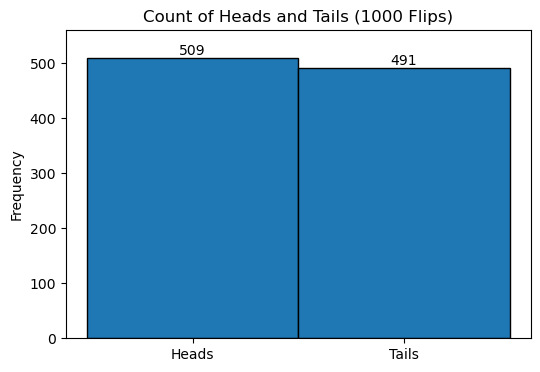

In [8]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

flips = rng.integers(0, 2, size=1000)
heads = np.sum(flips == 1)
tails = np.sum(flips == 0)

categories = ["Heads", "Tails"]
counts = [heads, tails]

plt.figure(figsize=(6, 4))
bars = plt.bar(categories, counts, width=1.0, edgecolor='black') # no gaps

# Add labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height)}",
             ha='center', va='bottom')

plt.title("Count of Heads and Tails (1000 Flips)")
plt.ylabel("Frequency")
plt.ylim(0, max(counts) * 1.1)
plt.show()

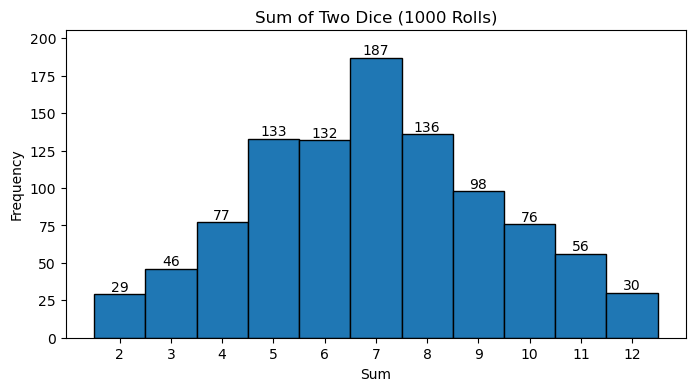

In [9]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

die1 = rng.integers(1, 7, size=1000)
die2 = rng.integers(1, 7, size=1000)
sums = die1 + die2

values = np.arange(2, 13)
counts = [np.sum(sums == v) for v in values]

plt.figure(figsize=(8, 4))
bars = plt.bar(values, counts, width=1.0, edgecolor='black') # no gaps

# Labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height)}",
             ha='center', va='bottom')

plt.title("Sum of Two Dice (1000 Rolls)")
plt.xlabel("Sum")
plt.ylabel("Frequency")
plt.xticks(values)
plt.ylim(0, max(counts) * 1.1)
plt.show()

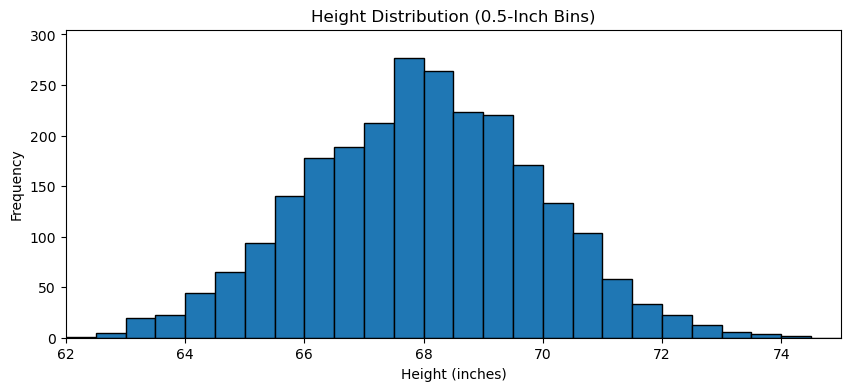

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

num_samples = 2500        # Adjust this

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("biometricdata.csv")

# Drop index column if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# ----------------------------
# Shuffle and sample
# ----------------------------
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_sample = df.head(num_samples)

heights = df_sample["Height"].to_numpy()
weights = df_sample["Weight"].to_numpy()

# 1/4 inch bins
bin_width = 1/2
bin_start = np.floor(heights.min())
bin_end = np.ceil(heights.max()) + bin_width
bins = np.arange(bin_start, bin_end, bin_width)

# Compute histogram
counts, bin_edges = np.histogram(heights, bins=bins)

plt.figure(figsize=(10, 4))

bars = plt.bar(
    bin_edges[:-1],
    counts,
    width=bin_width,
    align='edge',
    edgecolor='black'
)

# # Label bins (avoid clutter)
# for left, count in zip(bin_edges[:-1], counts):
#     if count > max(counts) * 0.05:  # label only larger bins
#         plt.text(left + bin_width / 2, count, str(int(count)),
#                  ha='center', va='bottom', fontsize=7)

plt.title("Height Distribution (0.5-Inch Bins)")
plt.xlabel("Height (inches)")
plt.ylabel("Frequency")
plt.xlim(bin_edges[0], bin_edges[-1])
plt.ylim(0, max(counts) * 1.1)

plt.show()

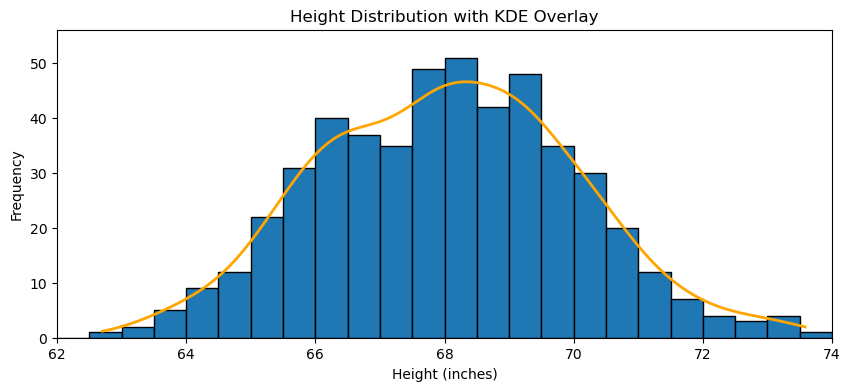

In [233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

num_samples = 500

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("biometricdata.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# ----------------------------
# Shuffle and sample
# ----------------------------
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_sample = df.head(num_samples)

heights = df_sample["Height"].to_numpy()
weights = df_sample["Weight"].to_numpy()

# ----------------------------
# Histogram setup
# ----------------------------
bin_width = 1/2   # 0.5 inch bins
bin_start = np.floor(heights.min())
bin_end = np.ceil(heights.max()) + bin_width
bins = np.arange(bin_start, bin_end, bin_width)

counts, bin_edges = np.histogram(heights, bins=bins)

# ----------------------------
# KDE computation
# ----------------------------
kde = gaussian_kde(heights)

x_grid = np.linspace(heights.min(), heights.max(), 500)
kde_values = kde(x_grid)

# Scale KDE to match histogram counts
kde_scaled = kde_values * len(heights) * bin_width

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 4))

# Histogram (counts)
plt.bar(
    bin_edges[:-1],
    counts,
    width=bin_width,
    align='edge',
    edgecolor='black'
)

# KDE overlay
plt.plot(x_grid, kde_scaled, linewidth=2,color="orange")

plt.title("Height Distribution with KDE Overlay")
plt.xlabel("Height (inches)")
plt.ylabel("Frequency")

plt.xlim(bin_edges[0], bin_edges[-1])
plt.ylim(0, max(counts) * 1.1)

plt.show()

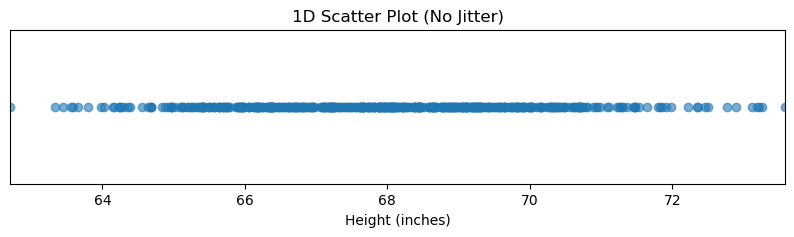

In [235]:
plt.figure(figsize=(10, 2))

plt.scatter(heights, np.zeros_like(heights), alpha=0.6)

plt.title("1D Scatter Plot (No Jitter)")
plt.xlabel("Height (inches)")
plt.yticks([])

plt.xlim(heights.min(), heights.max())

plt.show()

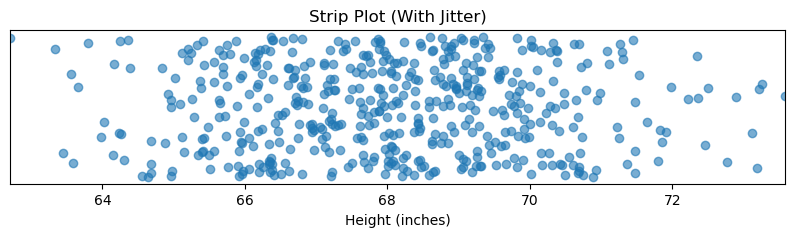

In [217]:
# Create jitter
np.random.seed(42)
jitter = np.random.uniform(-0.1, 0.1, size=len(heights))

plt.figure(figsize=(10, 2))

plt.scatter(heights, jitter, alpha=0.6)

plt.title("Strip Plot (With Jitter)")
plt.xlabel("Height (inches)")
plt.yticks([])

plt.xlim(heights.min(), heights.max())

plt.show()

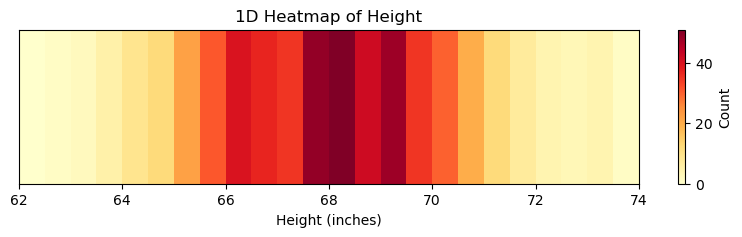

In [229]:
plt.figure(figsize=(10, 2))

# Bin the data
bin_width = 0.5
bin_start = np.floor(heights.min())
bin_end = np.ceil(heights.max()) + bin_width
bins = np.arange(bin_start, bin_end, bin_width)

counts, bin_edges = np.histogram(heights, bins=bins)

# Create grid for pcolormesh
X, Y = np.meshgrid(bin_edges, [0, 1])
Z = counts.reshape(1, -1)

# Plot heatmap
cmap = 'coolwarm'
cmap = 'YlOrRd'
# cmap='OrRd'
# cmap='Reds'
# cmap='inferno'

plt.pcolormesh(X, Y, Z, cmap=cmap, shading='flat')
plt.colorbar(label="Count")

plt.title("1D Heatmap of Height")
plt.xlabel("Height (inches)")
plt.yticks([])

plt.xlim(bin_edges[0], bin_edges[-1])

plt.show()

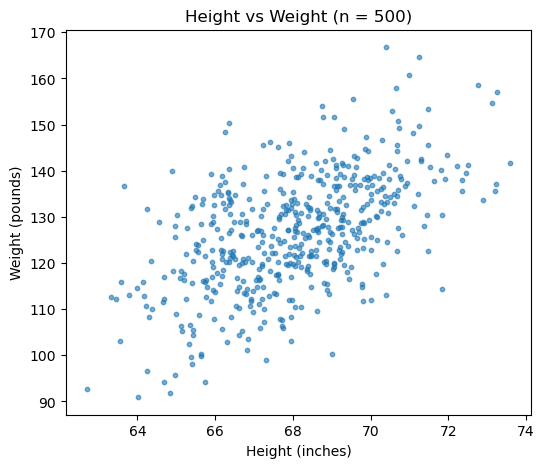

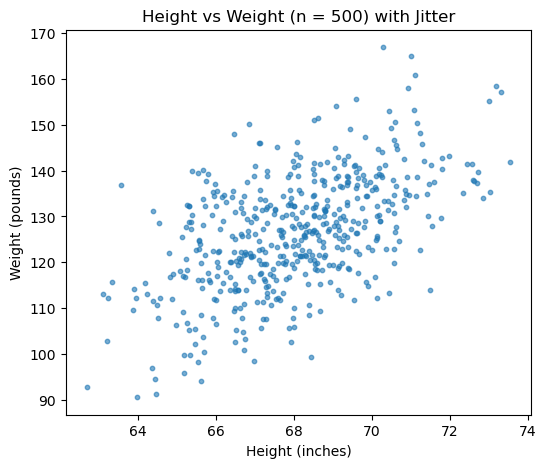

In [236]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Parameters
# ----------------------------

jitter_amount = 0.3      # Small noise (inches / pounds)



# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(6, 5))

plt.scatter(heights, weights, s=10, alpha=0.6)

plt.title(f"Height vs Weight (n = {num_samples})")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")

plt.show()



rng = np.random.default_rng(42)
heights = heights + rng.normal(0, jitter_amount, size=len(heights))
weights = weights + rng.normal(0, jitter_amount, size=len(weights))

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(6, 5))

plt.scatter(heights, weights, s=10, alpha=0.6)

plt.title(f"Height vs Weight (n = {num_samples}) with Jitter")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")

plt.show()

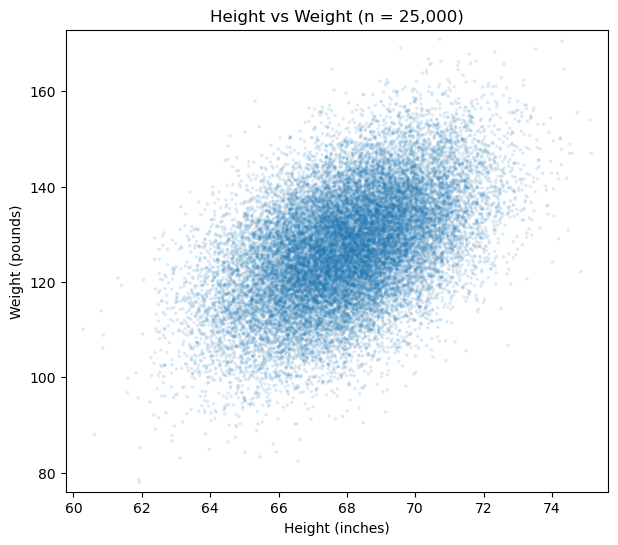

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("biometricdata.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

heights = df["Height"].to_numpy()
weights = df["Weight"].to_numpy()

plt.figure(figsize=(7, 6))

plt.scatter(
    heights,
    weights,
    s=6,              # small dots
    alpha=0.15,       # transparency helps reveal density
    edgecolors='none'
)

plt.title(f"Height vs Weight (n = {len(df):,})")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")

plt.xlim(heights.min() - 0.5, heights.max() + 0.5)
plt.ylim(weights.min() - 2, weights.max() + 2)

plt.show()

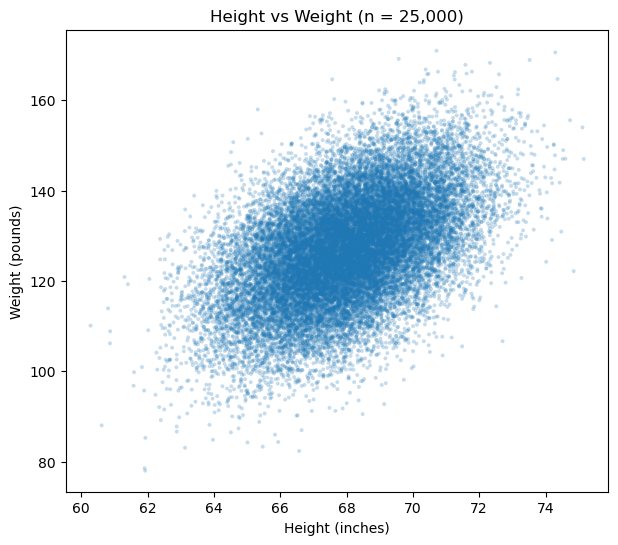

In [241]:
plt.figure(figsize=(7, 6))

plt.scatter(
    heights,
    weights,
    s=8,
    alpha=0.25,
    edgecolors='none'
)

plt.title(f"Height vs Weight (n = {len(df):,})")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")

plt.show()

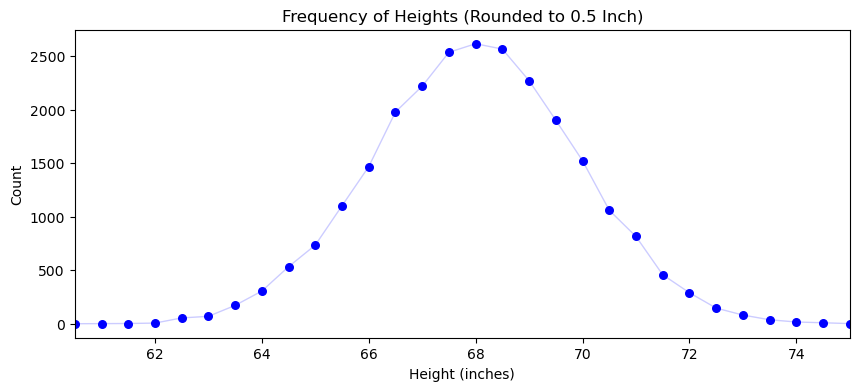

In [245]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Round to nearest 0.5 inch
# ----------------------------
heights_rounded = np.round(heights * 2) / 2

# ----------------------------
# Count frequencies
# ----------------------------
values, counts = np.unique(heights_rounded, return_counts=True)

# ----------------------------
# Line plot
# ----------------------------
plt.figure(figsize=(10, 4))

plt.plot(
    values,
    counts,
    color='blue',
    linewidth=1,
    alpha=0.2
)

plt.scatter(
    values,
    counts,
    s=30,
    color='blue'
)

plt.title("Frequency of Heights (Rounded to 0.5 Inch)")
plt.xlabel("Height (inches)")
plt.ylabel("Count")

plt.xlim(values.min(), values.max())

plt.show()

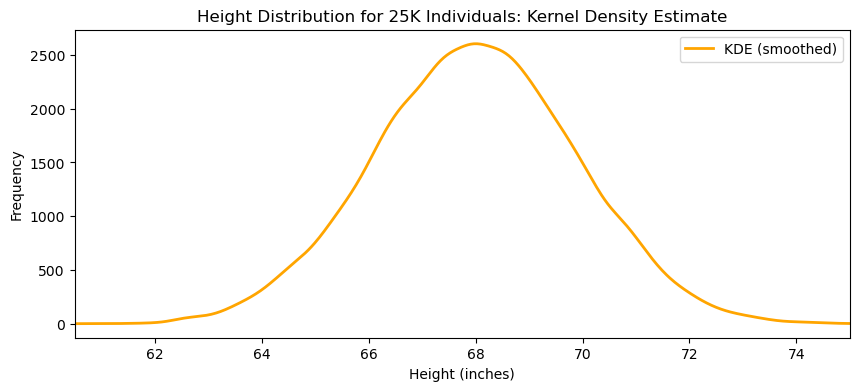

In [252]:
plt.figure(figsize=(10, 4))



# KDE (smooth curve)
plt.plot(
    x_grid,
    kde_scaled,
    color='orange',
    linewidth=2,
    label="KDE (smoothed)"
)

plt.title("Height Distribution for 25K Individuals: Kernel Density Estimate")
plt.xlabel("Height (inches)")
plt.ylabel("Frequency")

plt.xlim(values.min(), values.max())

plt.legend()

plt.show()

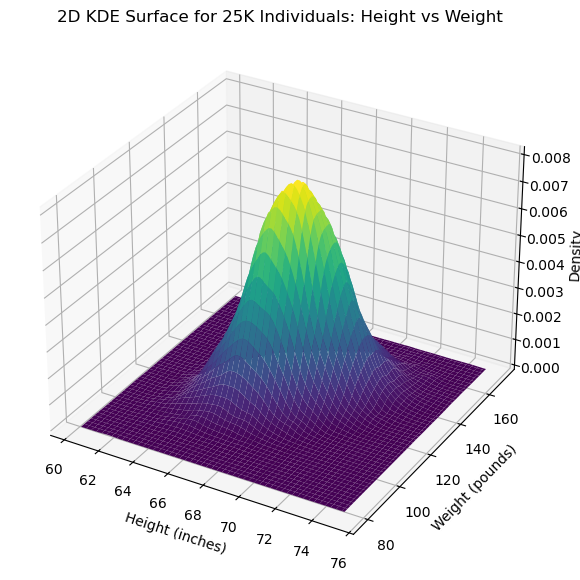

In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("biometricdata.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

heights = df["Height"].to_numpy()
weights = df["Weight"].to_numpy()

# ----------------------------
# KDE setup
# ----------------------------
values = np.vstack([heights, weights])
kde = gaussian_kde(values)

# Grid over the data range
x_grid = np.linspace(heights.min(), heights.max(), 100)
y_grid = np.linspace(weights.min(), weights.max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)

grid_coords = np.vstack([X.ravel(), Y.ravel()])
Z = kde(grid_coords).reshape(X.shape)

# ----------------------------
# 3D surface plot
# ----------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_title("2D KDE Surface for 25K Individuals: Height vs Weight")
ax.set_xlabel("Height (inches)")
ax.set_ylabel("Weight (pounds)")
ax.set_zlabel("Density")

plt.show()


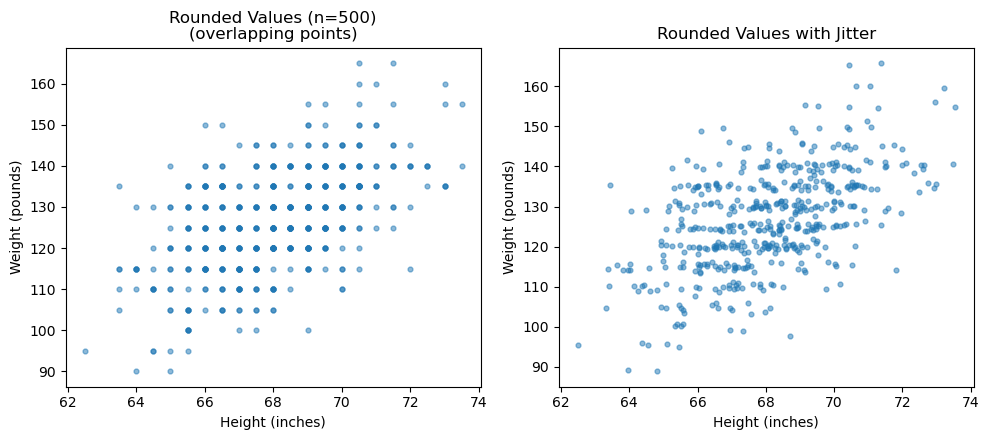

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Parameters
# ----------------------------
num_samples = 500
round_height_to = 1/2      # round to nearest 1 inch
round_weight_to = 5      # round to nearest 5 pounds
jitter_height = 0.15
jitter_weight = 0.8

# ----------------------------
# Load and shuffle data
# ----------------------------
df = pd.read_csv("biometricdata.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]


# Sample ONCE
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_sample = df.head(500)

heights = df_sample["Height"]
weights = df_sample["Weight"]

# ----------------------------
# Rounded values (create duplicates)
# ----------------------------
heights_round = round_height_to * np.round(heights / round_height_to)
weights_round = round_weight_to * np.round(weights / round_weight_to)

# ----------------------------
# Jittered version
# ----------------------------
rng = np.random.default_rng(42)
heights_jitter = heights_round + rng.normal(0, jitter_height, size=num_samples)
weights_jitter = weights_round + rng.normal(0, jitter_weight, size=num_samples)

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].scatter(heights_round, weights_round, s=12, alpha=0.5)
axes[0].set_title(f"Rounded Values (n={num_samples})\n(overlapping points)")
axes[0].set_xlabel("Height (inches)")
axes[0].set_ylabel("Weight (pounds)")

axes[1].scatter(heights_jitter, weights_jitter, s=12, alpha=0.5)
axes[1].set_title("Rounded Values with Jitter")
axes[1].set_xlabel("Height (inches)")
axes[1].set_ylabel("Weight (pounds)")

plt.tight_layout()
plt.show()

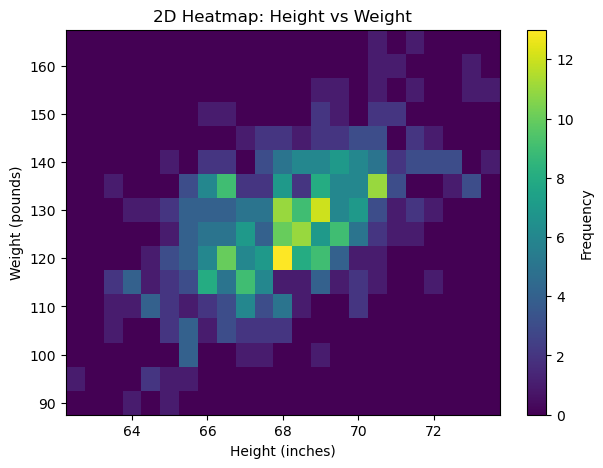

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Bin edges chosen to align with rounded values
x_edges = np.arange(heights_round.min() - 0.25,
                    heights_round.max() + 0.75,
                    0.5)
y_edges = np.arange(weights_round.min() - 2.5, weights_round.max() + 7.5, 5)

plt.figure(figsize=(7, 5))

plt.hist2d(heights_round, weights_round, bins=[x_edges, y_edges])
plt.colorbar(label="Frequency")

plt.title("2D Heatmap: Height vs Weight")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")

plt.show()

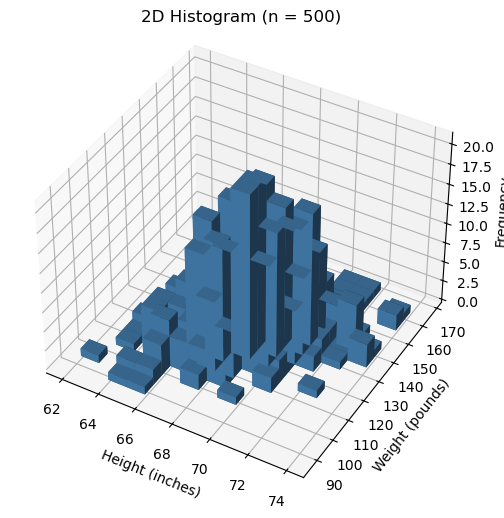

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# ----------------------------
# Histogram bins aligned to rounding
# ----------------------------
x_edges = np.arange(heights_round.min() - 0.5,
                    heights_round.max() + 1.5, 1)

y_edges = np.arange(weights_round.min() - 2.5,
                    weights_round.max() + 7.5, 5)

hist, xedges, yedges = np.histogram2d(
    heights_round, weights_round,
    bins=[x_edges, y_edges]
)

# ----------------------------
# Build bar positions
# ----------------------------
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")

xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)

dx = np.diff(xedges)[0] * np.ones_like(zpos)
dy = np.diff(yedges)[0] * np.ones_like(zpos)
dz = hist.ravel()

# Remove empty bins
mask = dz > 0
xpos, ypos, zpos = xpos[mask], ypos[mask], zpos[mask]
dx, dy, dz = dx[mask], dy[mask], dz[mask]

# ----------------------------
# Plot
# ----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=40, azim=-60)

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='steelblue', shade=True)

ax.set_title(f"2D Histogram (n = {num_samples})")
ax.set_xlabel("Height (inches)")
ax.set_ylabel("Weight (pounds)")
ax.set_zlabel("Frequency")

plt.show()

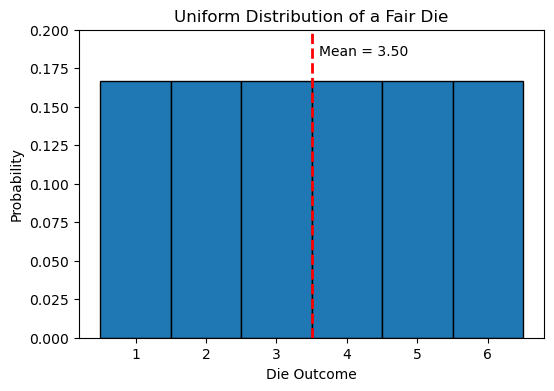

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Outcomes of a fair die
x = np.arange(1, 7)
p = np.ones_like(x) / 6  # uniform probabilities

# Compute statistics
mean = np.mean(x)
xmin, xmax = x.min(), x.max()

# Plot
plt.figure(figsize=(6, 4))
plt.bar(x, p, edgecolor='black',width=1.0)

# Labels and title
plt.xlabel("Die Outcome")
plt.ylabel("Probability")
plt.title("Uniform Distribution of a Fair Die")

# Show mean
plt.axvline(mean, linestyle='--', linewidth=2, color='r')
plt.text(mean + 0.1, max(p)*1.1, f"Mean = {mean:.2f}")

# Show range

# Ticks
plt.xticks(x)
plt.ylim(0, max(p)*1.2)

plt.show()

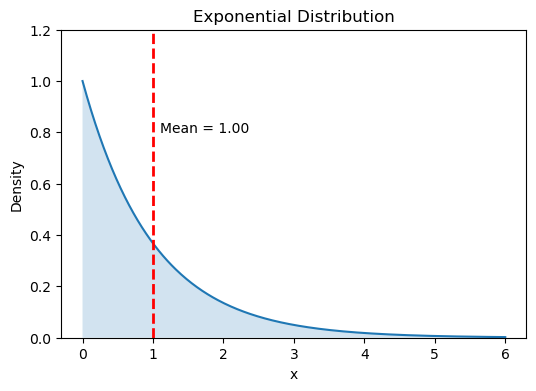

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter (rate)
lam = 1.0

# Domain (truncate for visualization)
x = np.linspace(0, 6, 400)

# PDF
y = lam * np.exp(-lam * x)

# Mean
mean = 1 / lam

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y)
plt.fill_between(x, y, alpha=0.2)

# Mean line
plt.axvline(mean, linestyle='--', linewidth=2,color='r')
plt.text(mean + 0.1, max(y)*0.8, f"Mean = {mean:.2f}")

# Labels
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Exponential Distribution")

plt.ylim(0, max(y)*1.2)

plt.show()

In [255]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('zillow-prize-1')

print("Path to competition files:", path)

UnauthenticatedError: User is not authenticated

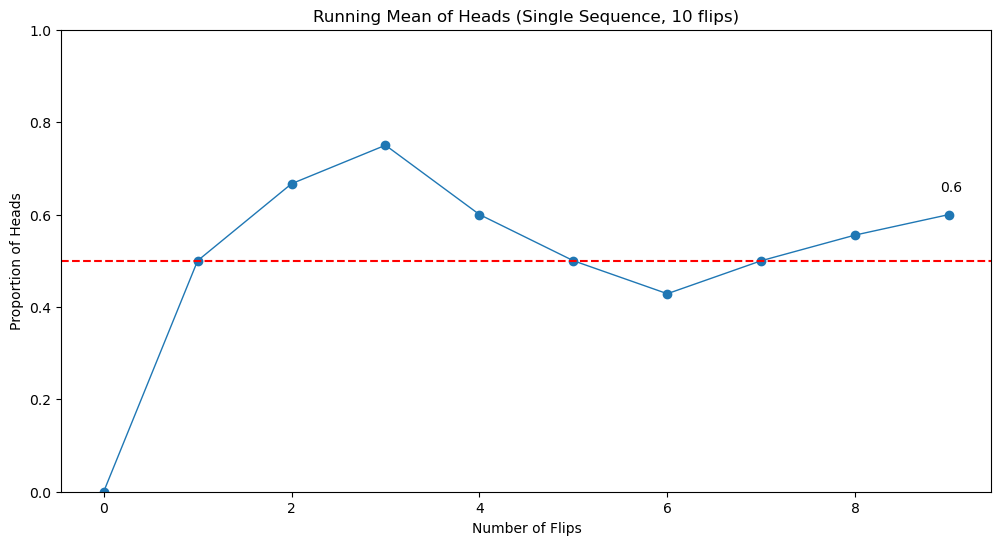

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Number of flips
n_flips = 10

# Simulate coin flips: 1 = heads, 0 = tails
flips = np.random.binomial(1, 0.5, size=n_flips)

# Running mean
running_mean = np.cumsum(flips) / np.arange(1, n_flips + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(running_mean, linewidth=1)
if n_flips < 101:
    plt.scatter(range(len(running_mean)),running_mean)

# True mean line
plt.axhline(0.5, linestyle='--',color='r')

# Labels
plt.title(f"Running Mean of Heads (Single Sequence, {n_flips} flips)")
plt.xlabel("Number of Flips")
plt.ylabel("Proportion of Heads")

plt.ylim(0, 1)

# Annotate final value with arrow
final_x = n_flips - 1
final_y = running_mean[-1]

plt.annotate(f"{final_y:.1f}",
             xy=(final_x, final_y),
             xytext=(final_x-0.1 , final_y + 0.05))
             # arrowprops=dict(arrowstyle="->"))

plt.show()

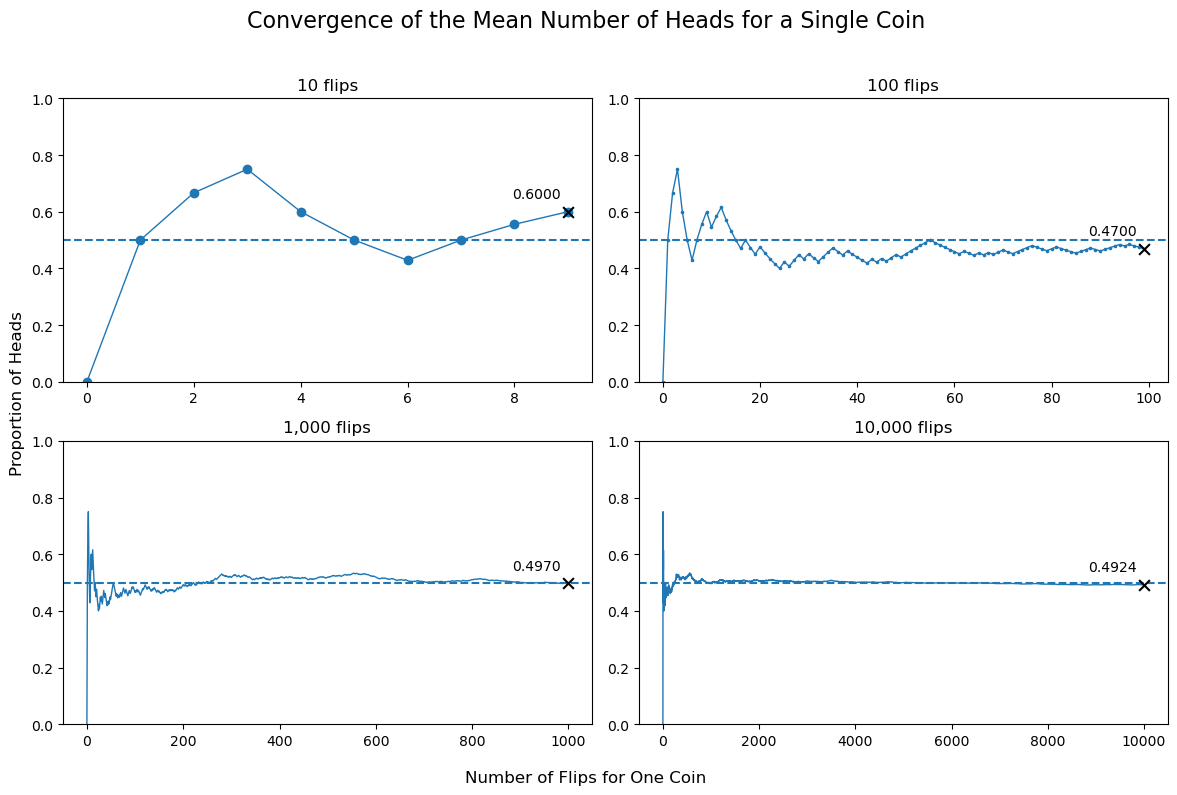

In [166]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Maximum size
max_flips = 10_000

# Generate ONE sequence
flips_all = np.random.binomial(1, 0.5, size=max_flips)

# Flip counts to display
flip_counts = [10, 100, 1000, 10_000]

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Convergence of the Mean Number of Heads for a Single Coin", fontsize=16)
axes = axes.flatten()

for ax, n_flips in zip(axes, flip_counts):

    # Slice the same sequence
    flips = flips_all[:n_flips]
    
    # Running mean
    running_mean = np.cumsum(flips) / np.arange(1, n_flips + 1)
    
    # Plot
    ax.plot(running_mean, linewidth=1)
    
    # Scatter for small n
    if n_flips <= 10:
        ax.scatter(range(n_flips), running_mean, marker='o')
    elif n_flips <= 100:
        ax.scatter(range(n_flips), running_mean, marker='.', s=10)
    
    # True mean
    ax.axhline(0.5, linestyle='--')
    
    # Final point
    final_x = n_flips - 1
    final_y = running_mean[-1]
    ax.scatter(final_x, final_y, marker='x', s=60, color='black', zorder=3)
    
    # Annotation (pixel offset)
    ax.annotate(f"{final_y:.4f}",
                xy=(final_x, final_y),
                xytext=(-40, 10),
                textcoords='offset points')
    
    # Titles
    ax.set_title(f"{n_flips:,} flips")
    ax.set_ylim(0, 1)

# Shared labels
fig.supxlabel("Number of Flips")
fig.supylabel("Proportion of Heads")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

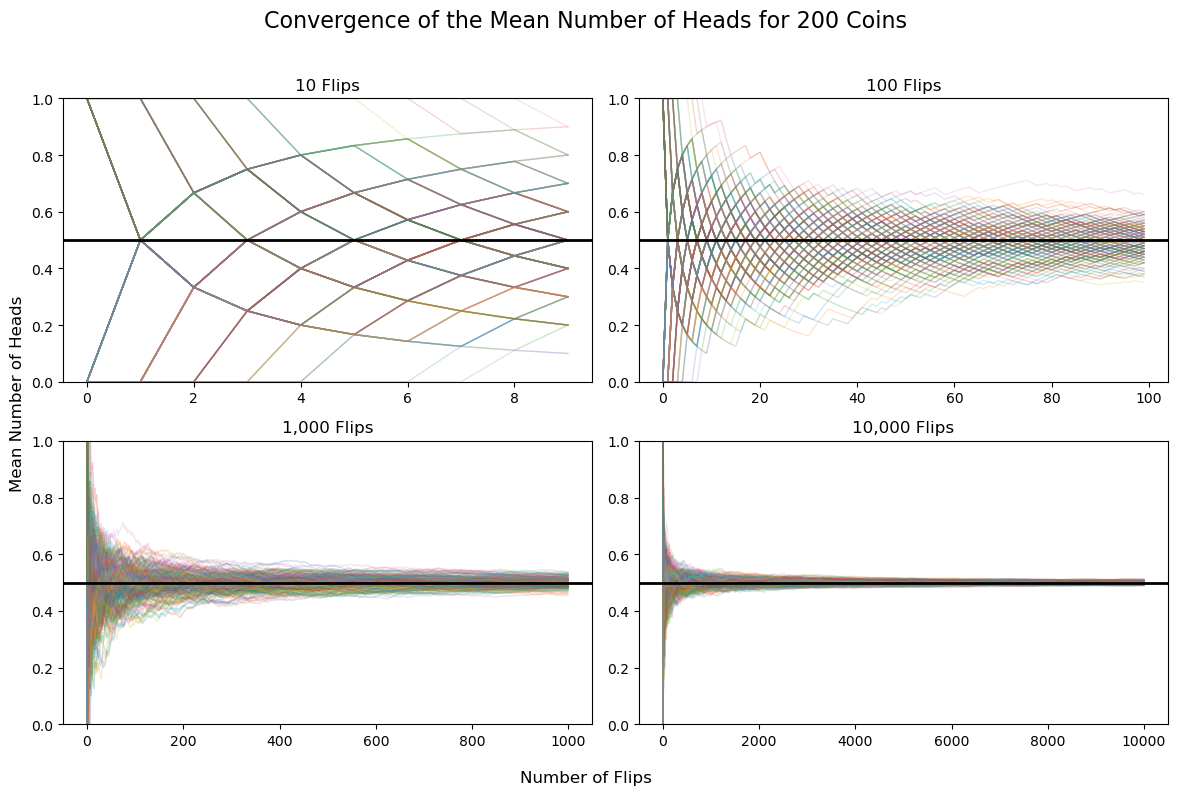

In [167]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_trials = 200
Ns = [10, 100, 1000, 10_000]
max_flips = max(Ns)

# Reproducibility
np.random.seed(42)

# Generate all sequences once
flips_all = np.random.binomial(1, 0.5, size=(n_trials, max_flips))

# Precompute running means for all trials
cumsum = np.cumsum(flips_all, axis=1)
running_means_all = cumsum / np.arange(1, max_flips + 1)

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Convergence of the Mean Number of Heads for {n_trials} Coins", fontsize=16)
axes = axes.flatten()

for ax, N in zip(axes, Ns):
    
    # Plot each trajectory truncated at N
    for trial in range(n_trials):
        ax.plot(running_means_all[trial, :N], alpha=0.2, linewidth=1)
    
    # True mean
    ax.axhline(0.5, color='black', linewidth=2)
    
    ax.set_title(f"{N:,} Flips")
    ax.set_ylim(0, 1)

# Shared labels
fig.supxlabel(f"Number of Flips")
fig.supylabel("Mean Number of Heads")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

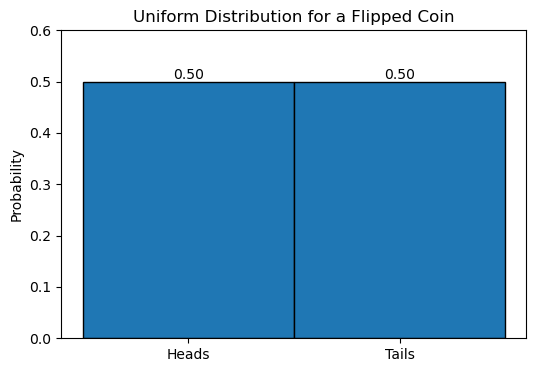

In [178]:
import matplotlib.pyplot as plt

categories = ["Heads", "Tails"]
probs = [0.5, 0.5]

plt.figure(figsize=(6, 4))
bars = plt.bar(categories, probs, width=1.0, edgecolor='black')

# Label probabilities on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom')

plt.title("Uniform Distribution for a Flipped Coin")
plt.ylabel("Probability")
plt.ylim(0, 0.6)

plt.show()

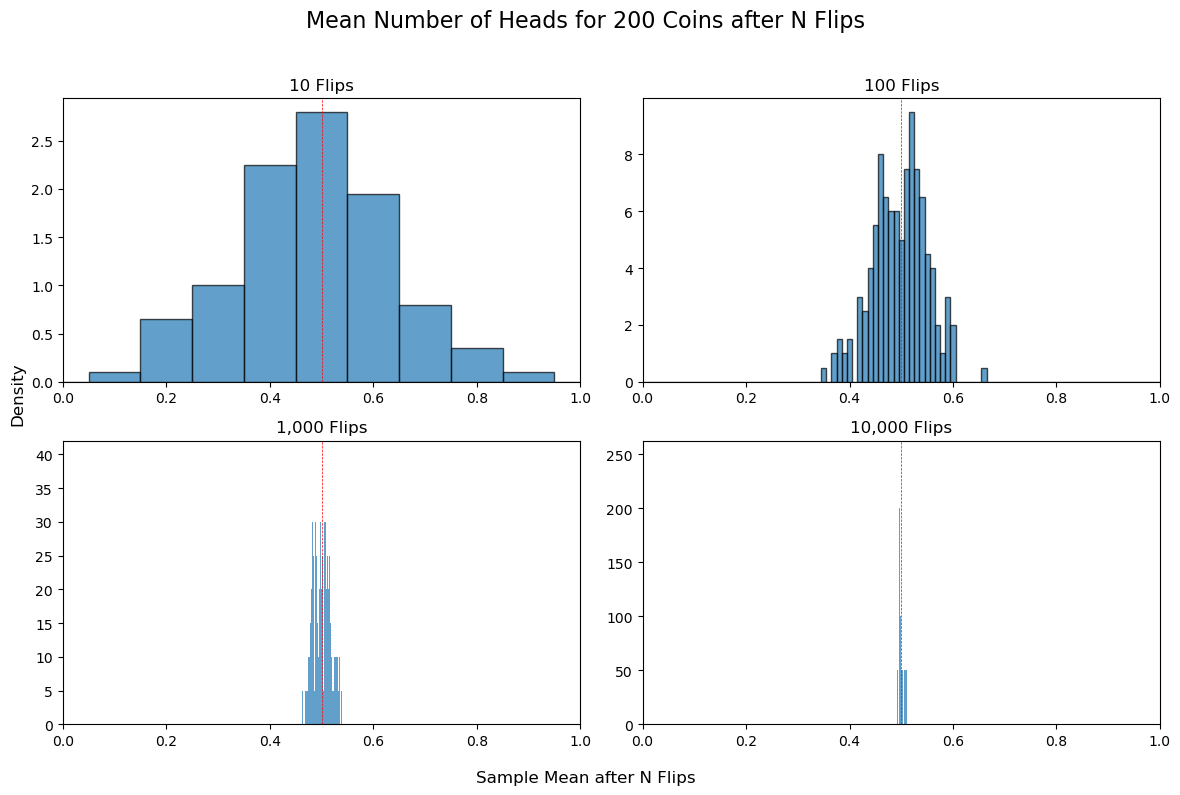

In [168]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_trials = 200
max_flips = 10_000
Ns = [10, 100, 1000, 10_000]

# Reproducibility
np.random.seed(42)

# Generate the same sequences for all panels
flips_all = np.random.binomial(1, 0.5, size=(n_trials, max_flips))

# Set up 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Mean Number of Heads for {n_trials} Coins after N Flips", fontsize=16)
axes = axes.flatten()

for ax, N in zip(axes, Ns):
    sample_means = flips_all[:, :N].mean(axis=1)

    if N < 1000:
        # Center bins on all possible sample mean values: 0, 1/N, 2/N, ..., 1
        half_step = 0.5 / N
        bin_edges = np.arange(-half_step, 1 + half_step + 1/N, 1/N)
        ax.hist(sample_means, bins=bin_edges, density=True,
                edgecolor='black', alpha=0.7)
    else:
        # For huge N, center fine bins around the observed range
        step = 1 / N
        xmin = sample_means.min()
        xmax = sample_means.max()
        bin_edges = np.arange(xmin - 0.5*step, xmax + 1.5*step, step)
        ax.hist(sample_means, bins=bin_edges, density=True,
                 alpha=0.7)

    # Mean line
    ax.axvline(0.5, color='red', linestyle='--', linewidth=0.5)

    # Title and limits
    ax.set_title(f"{N:,} Flips")
    ax.set_xlim(min(sample_means.min() - 0.05, 0), max(sample_means.max() + 0.05, 1))

fig.supxlabel(f"Sample Mean after N Flips")
fig.supylabel("Density")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

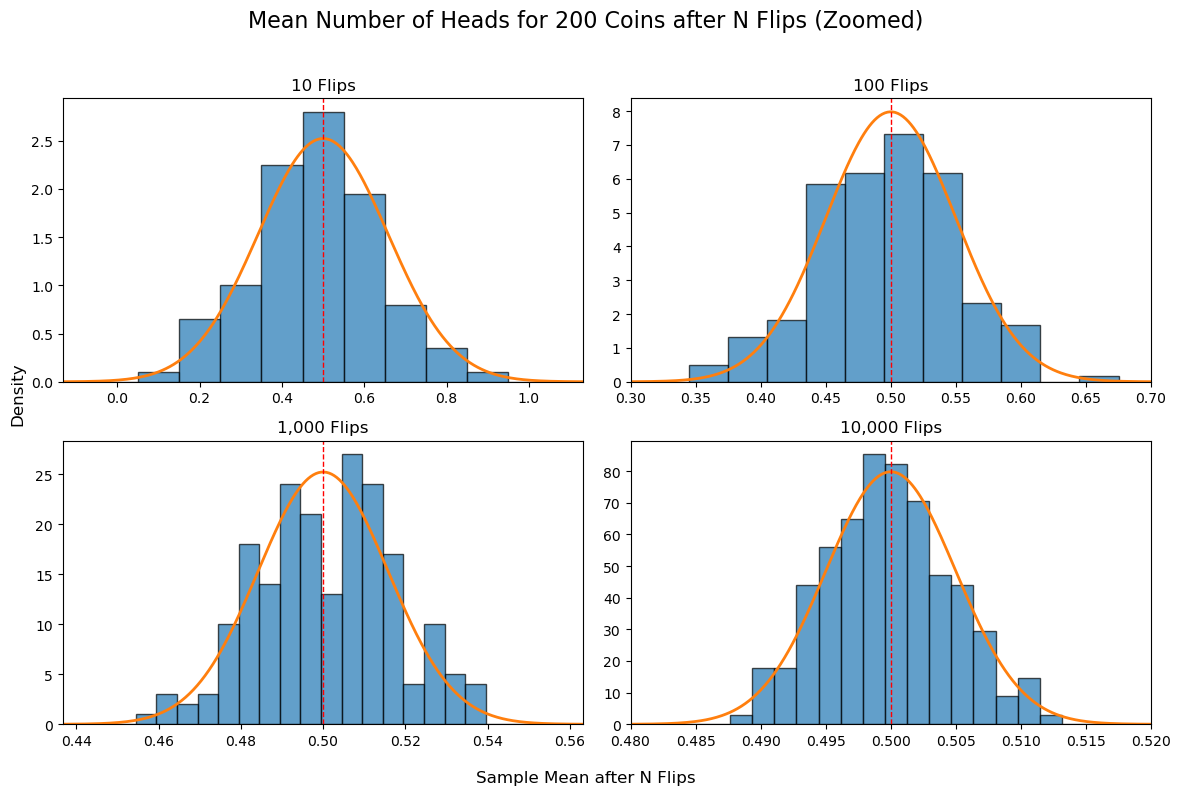

In [169]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_trials = 200
max_flips = 10_000
Ns = [10, 100, 1000, 10_000]

# Reproducibility
np.random.seed(42)

# Same sequences
flips_all = np.random.binomial(1, 0.5, size=(n_trials, max_flips))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Mean Number of Heads for {n_trials} Coins after N Flips (Zoomed)", fontsize=16)
axes = axes.flatten()

mu = 0.5

for ax, N in zip(axes, Ns):
    sample_means = flips_all[:, :N].mean(axis=1)

    sigma = np.sqrt(0.25 / N)
    step = 1 / N

    # Zoom range
    x_min = mu - 4 * sigma
    x_max = mu + 4 * sigma

    # Bin width = odd multiple of step, near sigma/3
    target_width = sigma / 3
    m = max(1, round(target_width / step))
    if m % 2 == 0:
        m += 1
    bin_width = m * step

    # Centers aligned to attainable means
    first_center = np.ceil(x_min / step) * step
    centers = np.arange(first_center, x_max + step, bin_width)

    # Edges from centers
    bin_edges = np.concatenate([
        centers - bin_width / 2,
        [centers[-1] + bin_width / 2]
    ])

    # Histogram
    ax.hist(sample_means, bins=bin_edges, density=True, alpha=0.7,edgecolor='black')

    # Normal overlay
    x = np.linspace(x_min, x_max, 400)
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))
    ax.plot(x, pdf, linewidth=2)

    # Mean line
    ax.axvline(mu, color='red', linestyle='--', linewidth=1)

    ax.set_title(f"{N:,} Flips")
    ax.set_xlim(x_min, x_max)

fig.supxlabel("Sample Mean after N Flips")
fig.supylabel("Density")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

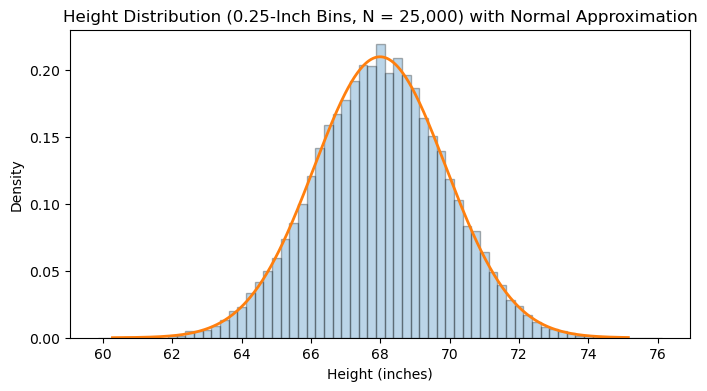

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("biometricdata.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

heights = df["Height"].to_numpy()

# ----------------------------
# Parameters
# ----------------------------
mu = np.mean(heights)
sigma = np.std(heights)

# ----------------------------
# 1/4 inch bins (centered)
# ----------------------------
bin_width = 0.25
bin_start = np.floor(heights.min()) - bin_width / 2
bin_end = np.ceil(heights.max()) + bin_width / 2 + bin_width
bins = np.arange(bin_start, bin_end, bin_width)

# ----------------------------
# Plot histogram
# ----------------------------
plt.figure(figsize=(8, 4))
plt.hist(heights, bins=bins, density=True, alpha=0.3, edgecolor='black')

# ----------------------------
# Normal overlay
# ----------------------------
x = np.linspace(heights.min(), heights.max(), 500)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma**2))
plt.plot(x, pdf, linewidth=2)

# ----------------------------
# Labels
# ----------------------------
plt.title("Height Distribution (0.25-Inch Bins, N = 25,000) with Normal Approximation")
plt.xlabel("Height (inches)")
plt.ylabel("Density")

plt.show()

$$ + \sigma$$
$$ + 2\sigma$$
$$ + 3\sigma$$

$$ - \sigma$$
$$ - 2\sigma$$
$$ - 3\sigma$$

$$\mu$$

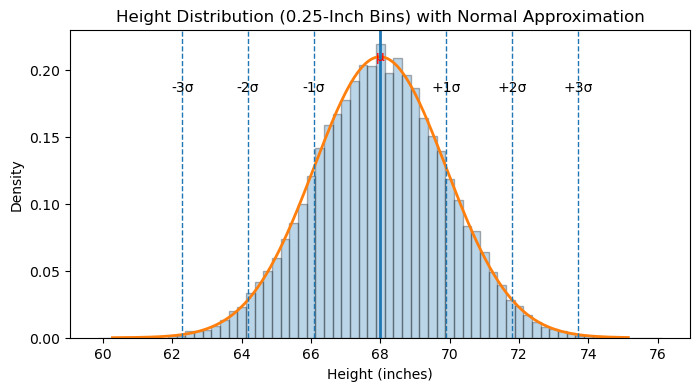

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("biometricdata.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

heights = df["Height"].to_numpy()

# ----------------------------
# Parameters
# ----------------------------
mu = np.mean(heights)
sigma = np.std(heights)

# ----------------------------
# 1/4 inch bins (centered)
# ----------------------------
bin_width = 0.25
bin_start = np.floor(heights.min()) - bin_width / 2
bin_end = np.ceil(heights.max()) + bin_width / 2 + bin_width
bins = np.arange(bin_start, bin_end, bin_width)

# ----------------------------
# Plot histogram
# ----------------------------
plt.figure(figsize=(8, 4))
plt.hist(heights, bins=bins, density=True, alpha=0.3, edgecolor='black')

# ----------------------------
# Normal overlay
# ----------------------------
x = np.linspace(heights.min(), heights.max(), 500)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma**2))
plt.plot(x, pdf, linewidth=2)

# ----------------------------
# Mean and sigma lines
# ----------------------------
plt.axvline(mu, linestyle='-', linewidth=2)  # mean

for k in [1, 2, 3]:
    plt.axvline(mu + k*sigma, linestyle='--', linewidth=1)
    plt.axvline(mu - k*sigma, linestyle='--', linewidth=1)

# ----------------------------
# Optional: labels (clean placement)
# ----------------------------
y_max = plt.ylim()[1]

plt.text(mu, y_max*0.9, "μ", ha='center',color='r')
for k in [1, 2, 3]:
    plt.text(mu + k*sigma, y_max*0.8, f"+{k}σ", ha='center')
    plt.text(mu - k*sigma, y_max*0.8, f"-{k}σ", ha='center')


# ----------------------------
# Labels
# ----------------------------
plt.title("Height Distribution (0.25-Inch Bins) with Normal Approximation")
plt.xlabel("Height (inches)")
plt.ylabel("Density")

plt.show()

In [184]:
# ----------------------------
# Display results with percent error
# ----------------------------
print(f"n = {n}")
print(f"Mean = {mu:.2f}, Std Dev = {sigma:.2f}\n")

print(f"{'Range':<6} {'Interval':<25} {'Actual':<10} {'Expected':<12} {'% Error':<10}")
print("-" * 75)

for label, low, high, actual, expected in results:
    percent_error = 100 * (actual - expected) / expected
    
    print(f"{label:<6} [{low:6.2f}, {high:6.2f}]   "
          f"{actual:<10} {expected:<12.1f} {percent_error:>8.2f}%")

n = 25000
Mean = 67.99, Std Dev = 1.90

Range  Interval                  Actual     Expected     % Error   
---------------------------------------------------------------------------
±1σ    [ 66.09,  69.89]   17089      17067.5          0.13%
±2σ    [ 64.19,  71.80]   23865      23862.5          0.01%
±3σ    [ 62.29,  73.70]   24949      24932.5          0.07%


In [ ]:
n = 25000
Mean = 67.99, Std Dev = 1.90

Range  Interval           Actual     Expected         % Error   
--------------------------------------------------------------
±1σ    [ 66.09,  69.89]   17089      17067.5          0.13%
±2σ    [ 64.19,  71.80]   23865      23862.5          0.01%
±3σ    [ 62.29,  73.70]   24949      24932.5          0.07%

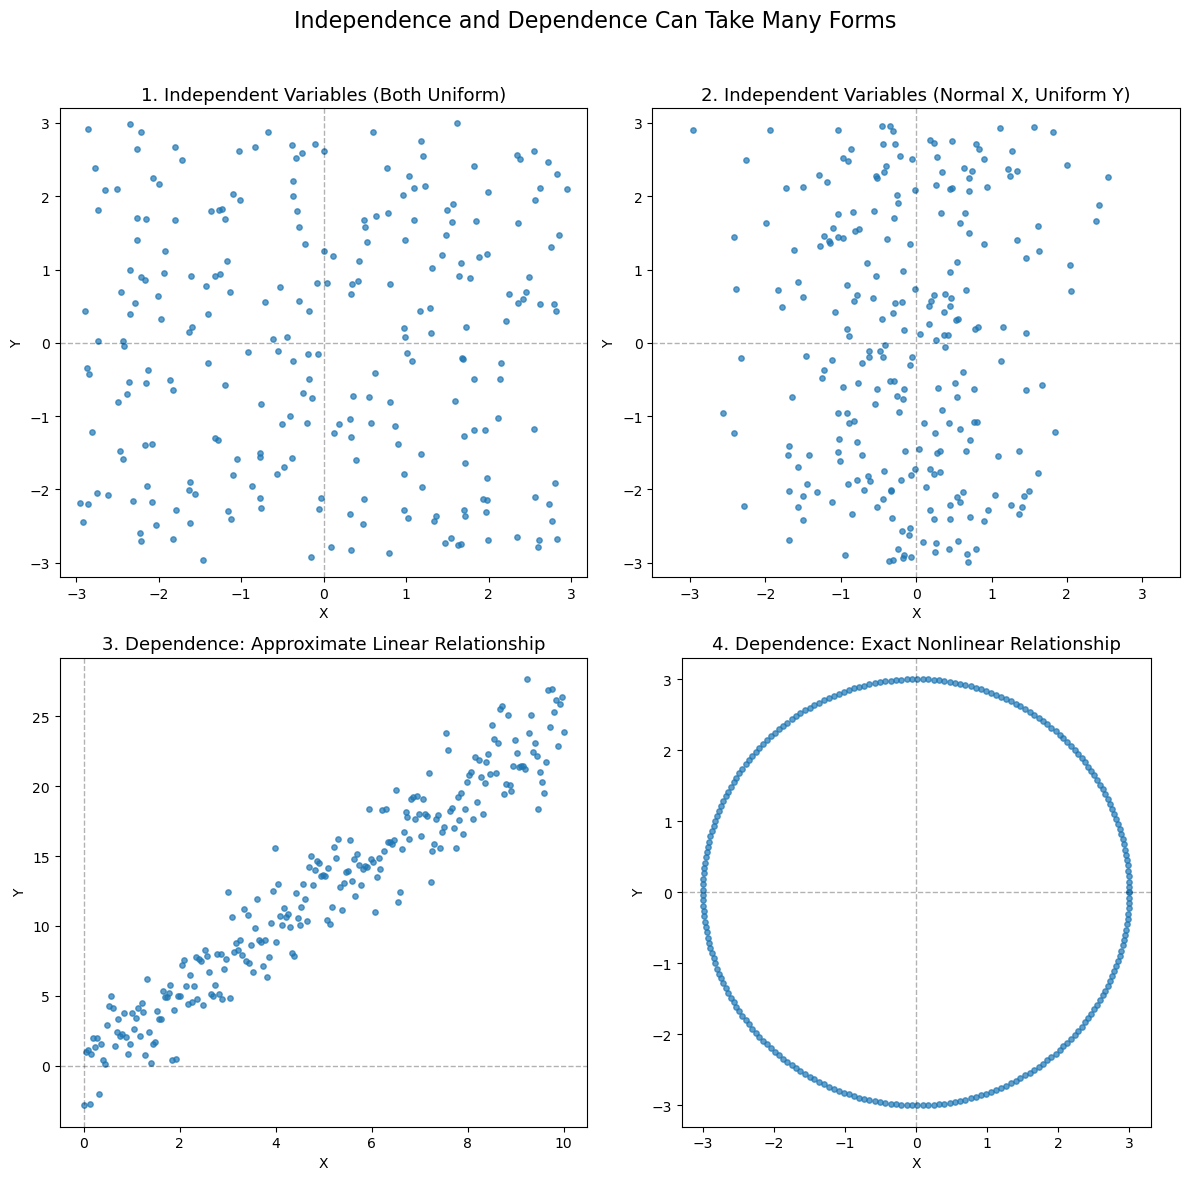

In [191]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for ax in axes:
    ax.axhline(0, linewidth=1, linestyle="--", alpha=0.3, color="black")
    ax.axvline(0, linewidth=1, linestyle="--", alpha=0.3, color="black")

n = 250

# ----------------------------
# Panel 1: Independent, both uniform
# ----------------------------
x1 = rng.uniform(-3, 3, n)
y1 = rng.uniform(-3, 3, n)

axes[0].scatter(x1, y1, s=15, alpha=0.7)
axes[0].set_title("1. Independent Variables (Both Uniform)", fontsize=13)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_xlim(-3.2, 3.2)
axes[0].set_ylim(-3.2, 3.2)

# ----------------------------
# Panel 2: Independent, different marginal distributions
# ----------------------------
x2 = rng.normal(0, 1, n)
y2 = rng.uniform(-3, 3, n)

axes[1].scatter(x2, y2, s=15, alpha=0.7)
axes[1].set_title("2. Independent Variables (Normal X, Uniform Y)", fontsize=13)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_xlim(-3.5, 3.5)
axes[1].set_ylim(-3.2, 3.2)

# ----------------------------
# Panel 3: Approximate linear dependence
# ----------------------------
x3 = np.linspace(0, 10, n)
y3 = 2.5 * x3 + rng.normal(0, 2.0, n)

axes[2].scatter(x3, y3, s=15, alpha=0.7)
axes[2].set_title("3. Dependence: Approximate Linear Relationship", fontsize=13)
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")

# ----------------------------
# Panel 4: Exact nonlinear dependence (circle)
# ----------------------------
theta = np.linspace(0, 2 * np.pi, n)
r = 3
x4 = r * np.cos(theta)
y4 = r * np.sin(theta)

axes[3].scatter(x4, y4, s=15, alpha=0.7)
axes[3].set_title("4. Dependence: Exact Nonlinear Relationship", fontsize=13)
axes[3].set_xlabel("X")
axes[3].set_ylabel("Y")
axes[3].set_xlim(-3.3, 3.3)
axes[3].set_ylim(-3.3, 3.3)
axes[3].set_aspect('equal', adjustable='box')

# Overall title
fig.suptitle(
    "Independence and Dependence Can Take Many Forms",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

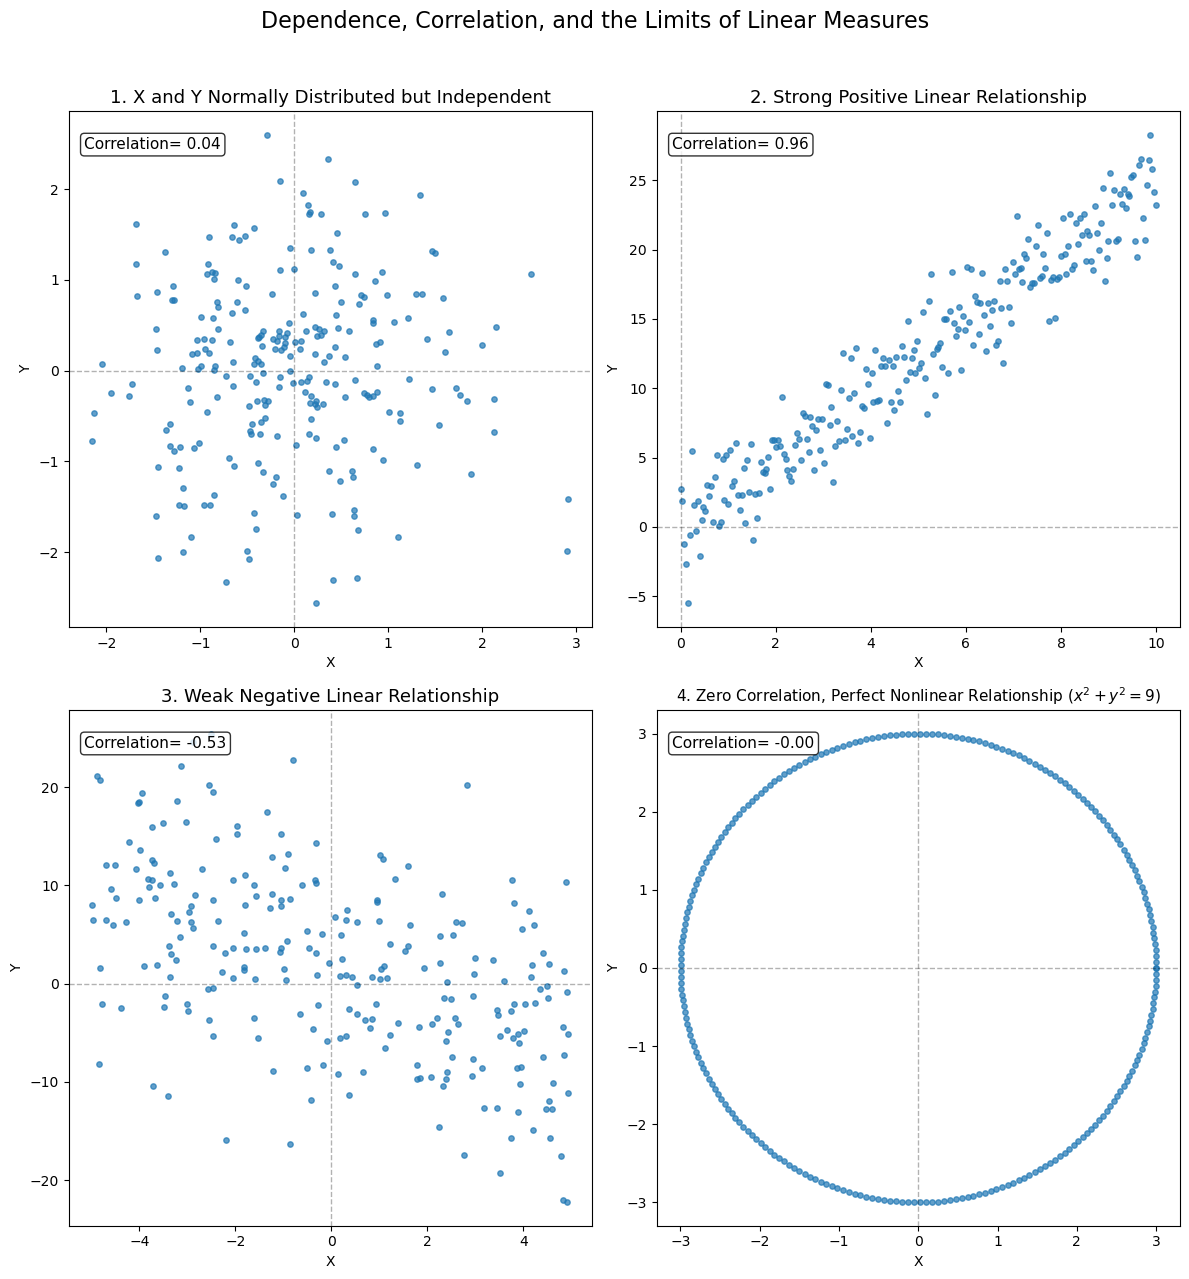

In [205]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(12, 13))
axes = axes.ravel()

for ax in axes:
    ax.axhline(0, linewidth=1, linestyle="--", alpha=0.3, color="black")
    ax.axvline(0, linewidth=1, linestyle="--", alpha=0.3, color="black")

n = 250

# ----------------------------
# Panel 1: No relationship
# ----------------------------
x1 = rng.normal(0, 1, n)
y1 = rng.normal(0, 1, n)

axes[0].scatter(x1, y1, s=15, alpha=0.7)
axes[0].set_title("1. X and Y Normally Distributed but Independent", fontsize=13)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].text(
    0.03, 0.95,
    f"Correlation= {np.corrcoef(x1, y1)[0,1]:.2f}",
    transform=axes[0].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
)

# ----------------------------
# Panel 2: Strong positive linear relationship
# ----------------------------
x2 = np.linspace(0, 10, n)
y2 = 2.5 * x2 + rng.normal(0, 2.0, n)

axes[1].scatter(x2, y2, s=15, alpha=0.7)
axes[1].set_title("2. Strong Positive Linear Relationship", fontsize=13)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].text(
    0.03, 0.95,
    f"Correlation= {np.corrcoef(x2, y2)[0,1]:.2f}",
    transform=axes[1].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
)

# ----------------------------
# Panel 3: Strong negative linear relationship (different structure)
# ----------------------------
x3 = rng.uniform(-5, 5, n)                      # different X distribution
y3 = -1.5 * x3 + rng.normal(0, 8.0, n) + 2      # different slope, less noise, vertical shift

axes[2].scatter(x3, y3, s=15, alpha=0.7)
axes[2].set_title("3. Weak Negative Linear Relationship", fontsize=13)
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")
axes[2].text(
    0.03, 0.95,
    f"Correlation= {np.corrcoef(x3, y3)[0,1]:.2f}",
    transform=axes[2].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
)
# ----------------------------
# Panel 4: Perfect circle (correlation ~ 0)
# ----------------------------
theta = np.linspace(0, 2*np.pi, n)
r = 3

x4 = r * np.cos(theta)
y4 = r * np.sin(theta)

axes[3].scatter(x4, y4, s=15, alpha=0.7)
axes[3].set_title("4. Zero Correlation, Perfect Nonlinear Relationship ($x^2 + y^2 = 9$)", fontsize=11)
axes[3].set_xlabel("X")
axes[3].set_ylabel("Y")
axes[3].text(
    0.03, 0.95,
    f"Correlation= {np.corrcoef(x4, y4)[0,1]:.2f}",
    transform=axes[3].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
)

# Overall title
fig.suptitle(
    "Dependence, Correlation, and the Limits of Linear Measures",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

$$
\text{Correlation}(X,Y) = \frac{\text{Mean}\left[(X - \mu_X)(Y - \mu_Y)\right]}{\sigma_X \sigma_Y}
$$




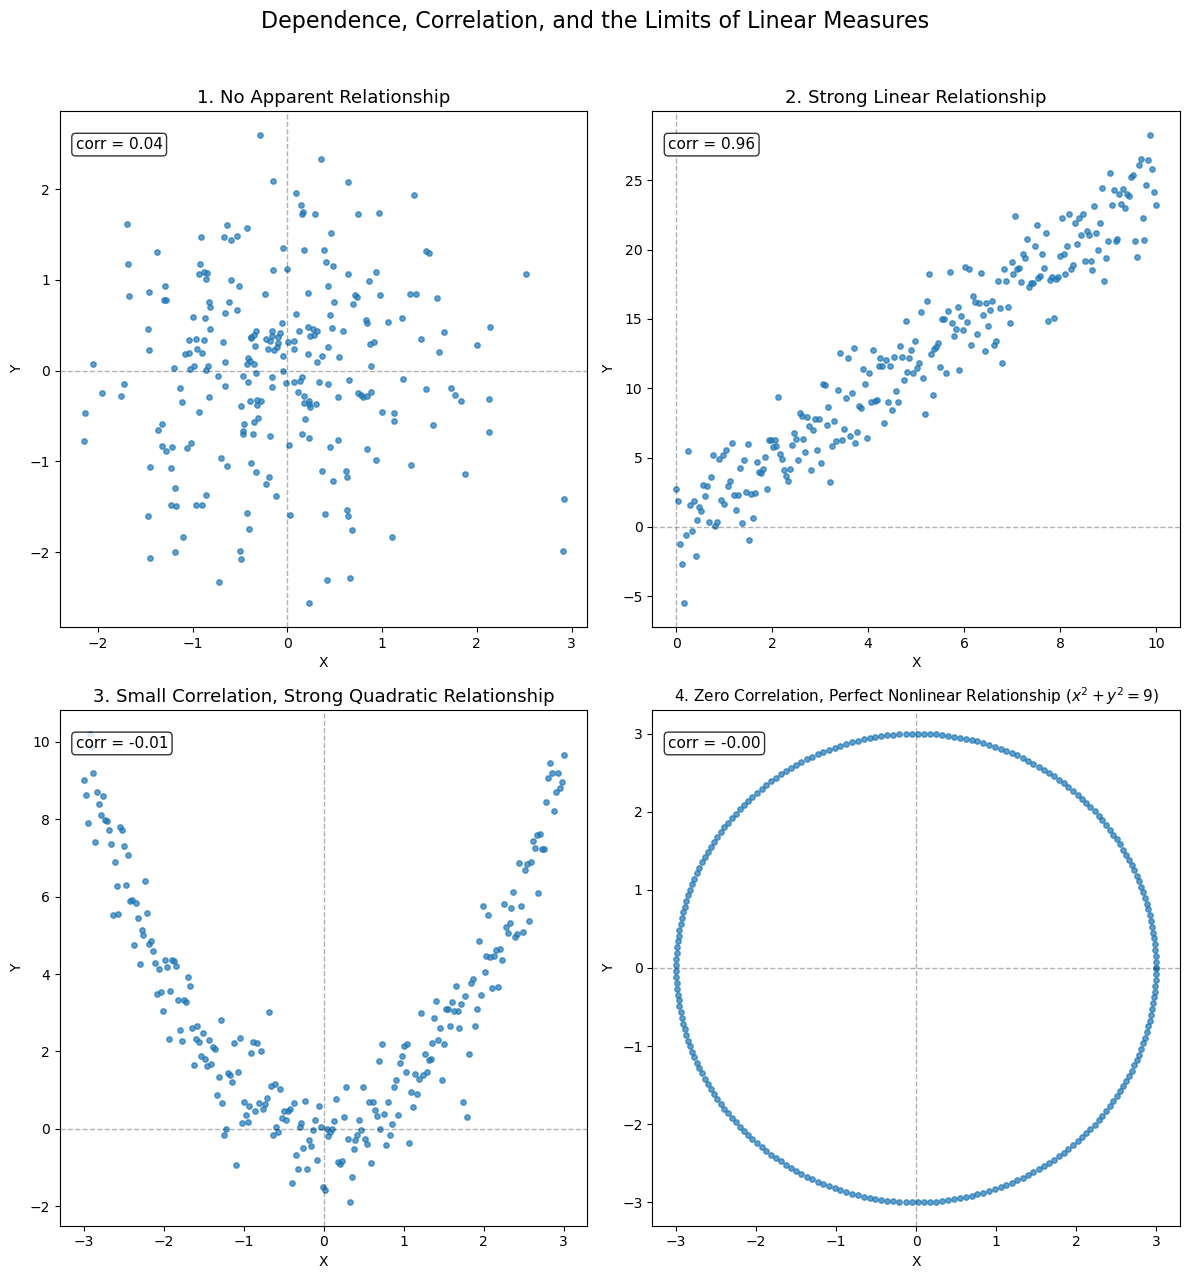

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(12, 13))
axes = axes.ravel()

for ax in axes:
    ax.axhline(0, linewidth=1, linestyle="--", alpha=0.3,color="black")
    ax.axvline(0, linewidth=1, linestyle="--", alpha=0.3,color="black")

# ----------------------------
# Panel 1: No relationship
# ----------------------------
n = 250
x1 = rng.normal(0, 1, n)
y1 = rng.normal(0, 1, n)

axes[0].scatter(x1, y1, s=15, alpha=0.7)
axes[0].set_title("1. No Apparent Relationship", fontsize=13)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].text(
    0.03, 0.95,
    f"Correlation= {np.corrcoef(x1, y1)[0,1]:.2f}",
    transform=axes[0].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
)

# ----------------------------
# Panel 2: Strong linear relationship
# ----------------------------
x2 = np.linspace(0, 10, n)
y2 = 2.5 * x2 + rng.normal(0, 2.0, n)

axes[1].scatter(x2, y2, s=15, alpha=0.7)
axes[1].set_title("2. Strong Linear Relationship", fontsize=13)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].text(
    0.03, 0.95,
    f"Correlation= {np.corrcoef(x2, y2)[0,1]:.2f}",
    transform=axes[1].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
)

# ----------------------------
# Panel 3: Nonlinear relationship
# ----------------------------
x3 = np.linspace(-3, 3, n)
y3 = x3**2 + rng.normal(0, 0.8, n)

axes[2].scatter(x3, y3, s=15, alpha=0.7)
axes[2].set_title("3. Small Correlation, Strong Quadratic Relationship", fontsize=13)
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")
axes[2].text(
    0.03, 0.95,
    f"Correlation= {np.corrcoef(x3, y3)[0,1]:.2f}",
    transform=axes[2].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
)

# ----------------------------
# Panel 4: Perfect circle (correlation ~ 0)
# ----------------------------
theta = np.linspace(0, 2*np.pi, n)
r = 3

x4 = r * np.cos(theta)
y4 = r * np.sin(theta)

# Optional: add very small noise to avoid numerical artifacts
# x4 += rng.normal(0, 0.05, n)
# y4 += rng.normal(0, 0.05, n)

axes[3].scatter(x4, y4, s=15, alpha=0.7)
axes[3].set_title("4. Zero Correlation, Perfect Nonlinear Relationship ($x^2 + y^2 = 9$)", fontsize=11)
axes[3].set_xlabel("X")
axes[3].set_ylabel("Y")

axes[3].text(
    0.03, 0.95,
    f"Correlation= {np.corrcoef(x4, y4)[0,1]:.2f}",
    transform=axes[3].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
)

# Overall title
fig.suptitle(
    "Dependence, Correlation, and the Limits of Linear Measures",
    fontsize=16,
    y=0.98
)



plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

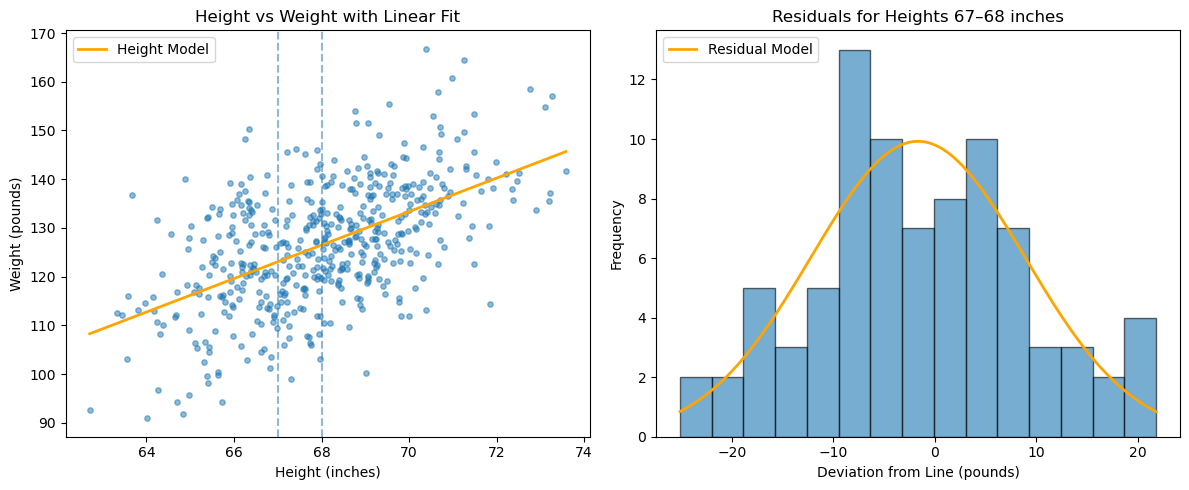

In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("biometricdata.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Sample 500 points (consistent)
df = df.sample(n=500, random_state=42)

heights = df["Height"].to_numpy()
weights = df["Weight"].to_numpy()

# ----------------------------
# Fit linear regression
# ----------------------------
coef = np.polyfit(heights, weights, 1)
slope, intercept = coef

x_line = np.linspace(heights.min(), heights.max(), 200)
y_line = slope * x_line + intercept

# ----------------------------
# Residuals
# ----------------------------
predicted = slope * heights + intercept
residuals = weights - predicted

# Slice: heights 67–68 inches
mask = (heights >= 67) & (heights <= 68)
residuals_slice = residuals[mask]

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_color = "orange"

# --- Plot 1: Scatter + regression ---
axes[0].scatter(heights, weights, s=15, alpha=0.5)
axes[0].plot(x_line, y_line, linewidth=2, color=model_color)

axes[0].set_title("Height vs Weight with Linear Fit")
axes[0].set_xlabel("Height (inches)")
axes[0].set_ylabel("Weight (pounds)")
# Custom legend handle (line only)
model_line = Line2D([0], [0], color=model_color, linewidth=2)

axes[0].legend([model_line], ["Height Model"], loc="upper left")

# Optional: show slice region visually
axes[0].axvline(67, linestyle="--", alpha=0.5)
axes[0].axvline(68, linestyle="--", alpha=0.5)

# --- Plot 2: Histogram (frequency) ---
counts, bins, _ = axes[1].hist(
    residuals_slice,
    bins=15,
    edgecolor='black',
    alpha=0.6
)

# Normal model overlay (scaled)
mu = np.mean(residuals_slice)
sigma = np.std(residuals_slice)

x = np.linspace(bins[0], bins[-1], 200)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2))

bin_width = bins[1] - bins[0]
scaled_pdf = pdf * len(residuals_slice) * bin_width

axes[1].plot(x, scaled_pdf, linewidth=2, color=model_color)

axes[1].set_title("Residuals for Heights 67–68 inches")
axes[1].set_xlabel("Deviation from Line (pounds)")
axes[1].set_ylabel("Frequency")
axes[1].legend([model_line],["Residual Model"], loc="upper left")

plt.tight_layout()
plt.show()

Yes. The diagram now implies a broader and more accurate story than the surrounding text. The current text still presents categorical representation as essentially a choice among **strings, integer labels, and one-hot vectors**, which is too narrow and also mixes two different ideas:

* how categories are **stored** in a dataset, and
* how they are **encoded for modeling**.

Strings are usually the original representation, not an encoding strategy for most models.

## Suggested revised heading

### Representing and Encoding Categorical Features

## Suggested replacement text

> Categorical features are often stored as text labels, but most machine learning algorithms require numerical input. Before modeling, categorical values therefore usually need to be converted into a numerical representation.
>
> The appropriate encoding depends partly on whether the categories are **ordinal** or **nominal**. Ordinal categories have a meaningful order and can often be represented by ordered integer labels. Nominal categories have no natural order, so assigning arbitrary integers may incorrectly suggest numerical relationships between them.
>
> **One-hot encoding** is the standard approach for nominal variables with a manageable number of categories. It creates a separate binary feature for each category. However, when a feature has many categories, one-hot encoding can greatly increase the number of columns. Alternatives include **grouping infrequent categories**, **frequency encoding**, and **target encoding**. These methods are more compact, but they may discard information or introduce additional modeling risks.

That introduces the broader range without trying to teach every method in Week 2.

## I would also revise the first table

The current table’s **Integer Label** column could mislead students because the example is nominal:

| Category    | Stored as text  | Integer label | One-hot representation |
| ----------- | --------------- | ------------: | ---------------------- |
| Residential | `"residential"` |             0 | `[1, 0, 0]`            |
| Commercial  | `"commercial"`  |             1 | `[0, 1, 0]`            |
| Industrial  | `"industrial"`  |             2 | `[0, 0, 1]`            |

That is still useful, but I would explicitly label the integer version as:

> **Arbitrary integer label—not normally appropriate for a nominal predictor**

Otherwise, students may conclude that integer encoding is an equally valid model input for these categories.

You could add a sentence immediately beneath the table:

> Because these categories are nominal, the labels 0, 1, and 2 are only identifiers. Using them directly in a model may incorrectly imply that the categories are ordered or numerically spaced.

## Revised advantages/disadvantages table

I would replace the existing three-row table with this:

| Representation or encoding      | Advantages                                              | Disadvantages                                                                                 |
| ------------------------------- | ------------------------------------------------------- | --------------------------------------------------------------------------------------------- |
| **Text labels**                 | Human-readable; clearly identifies categories           | Most models cannot use strings directly                                                       |
| **Ordinal encoding**            | Compact; preserves a meaningful category order          | Appropriate only when the ordering is genuine                                                 |
| **One-hot encoding**            | Introduces no artificial ordering; widely supported     | Can create many features when cardinality is high                                             |
| **Group infrequent categories** | Reduces dimensionality and rare-category noise          | Combines categories and may lose information                                                  |
| **Frequency encoding**          | Compact; uses only one numerical feature                | Different categories may receive the same value; frequency may not reflect predictive meaning |
| **Target encoding**             | Compact and can capture strong predictive relationships | Can cause data leakage and overfitting if not fitted carefully                                |

For Week 2, that may be slightly too much detail on screen. A more restrained version would combine the last three:

| Representation or encoding    | Advantages                                          | Disadvantages                                             |
| ----------------------------- | --------------------------------------------------- | --------------------------------------------------------- |
| **Text labels**               | Human-readable                                      | Usually cannot be used directly by models                 |
| **Ordinal encoding**          | Compact; preserves meaningful order                 | Only appropriate for genuinely ordered categories         |
| **One-hot encoding**          | No artificial ordering; simple and widely supported | Can produce many features                                 |
| **Compact nominal encodings** | Reduce the number of generated features             | May lose information or introduce leakage and overfitting |

Then define “compact nominal encodings” in the paragraph as grouping, frequency, and target encoding.

## Pedagogical recommendation

I would still make **one-hot encoding the main method taught in Week 2**. The others should be introduced as alternatives rather than taught procedurally. Something like this would set the right expectation:

> In this course, one-hot encoding will be our default method for nominal variables. Later, we will consider alternatives when a feature contains many categories or one-hot encoding becomes computationally expensive.

That gives students the full conceptual picture while preserving a clear default workflow.


## Week 4

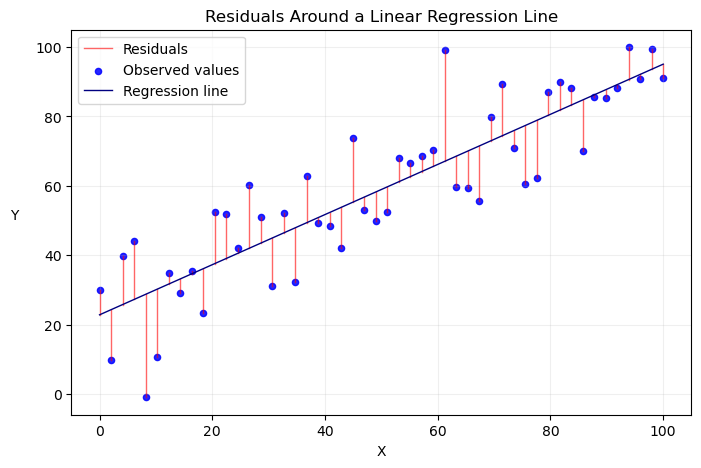

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Reproducible data
rng = np.random.default_rng(42)

# Generate fewer points with constant variance
n = 50
X = np.linspace(0, 100, n)
noise = rng.normal(loc=0, scale=16, size=n)
y = 25 + 0.65 * X + noise

# Fit linear regression
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)
y_hat = model.predict(X.reshape(-1, 1))

# Plot
plt.figure(figsize=(8, 5))

# Residual lines (now red)
for i, (xi, yi, yhi) in enumerate(zip(X, y, y_hat)):
    if i == 0:
        plt.plot([xi, xi], [yi, yhi],
                 color="red", linewidth=1, alpha=0.6,
                 label="Residuals")
    else:
        plt.plot([xi, xi], [yi, yhi],
                 color="red", linewidth=1, alpha=0.6)

# Data points (now blue)
plt.scatter(X, y, color="blue", s=20, alpha=0.85, label="Observed values")

# Regression line (keep blue, slightly darker/thicker for distinction)
plt.plot(X, y_hat, color="navy", linewidth=1, label="Regression line")

plt.xlabel("X")
plt.ylabel("Y", rotation=0, labelpad=15)
plt.title("Residuals Around a Linear Regression Line")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

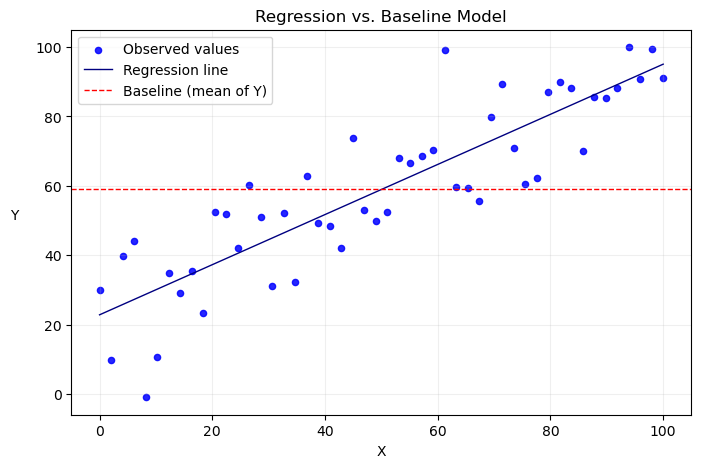

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Reproducible data
rng = np.random.default_rng(42)

# Generate data
n = 50
X = np.linspace(0, 100, n)
noise = rng.normal(loc=0, scale=16, size=n)
y = 25 + 0.65 * X + noise

# Fit linear regression
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)
y_hat = model.predict(X.reshape(-1, 1))

# Baseline model (mean of Y)
y_mean = np.mean(y)

# Plot
plt.figure(figsize=(8, 5))

# Data points
plt.scatter(X, y, color="blue", s=20, alpha=0.85, label="Observed values")

# Regression line
plt.plot(X, y_hat, color="navy", linewidth=1, label="Regression line")

# Baseline model (horizontal line at mean of Y)
plt.axhline(y=y_mean, color="red", linestyle="--", linewidth=1,
            label="Baseline (mean of Y)")

plt.xlabel("X")
plt.ylabel("Y", rotation=0, labelpad=15)
plt.title("Regression vs. Baseline Model")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

$$ \mathrm{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right| $$ 


$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \mu_Y)^2}
$$

## Week 5

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$


I think this is pedagogically quite solid overall. The progression:

1. logistic outputs probabilities
2. MSE is not ideal
3. introduce cross-entropy
4. optimize with gradient descent

is very coherent for an introductory ML course.

There are, however, a few places where I would tighten the mathematical story and improve the transition between the figures.

---

# Main Issue

Right now the text says:

> “the MSE doesn't align well with the logit transformation's output”

That explanation is not quite right mathematically, and stronger students may find it vague.

The real issue is:

* MSE produces a non-convex optimization problem when combined with the sigmoid,
* and cross-entropy strongly penalizes confident incorrect predictions.

For beginners, you do *not* need to discuss convexity formally, but you should make the motivation more precise.

---

# Suggested Rewrite of the Opening

I would replace the first paragraph with something like this:

---

## Training a Logistic Regression Model (Optimization)

To train a logistic regression model, we must determine the parameters (\beta) that produce probabilities close to the correct class labels.

For each training example, the model outputs a probability (p^{(i)}\in(0,1)), while the true label is either:

* (y^{(i)} = 1) for the positive class, or
* (y^{(i)} = 0) for the negative class.

We therefore need a cost function that measures how well the predicted probabilities match the true labels.

Although Mean Squared Error (MSE) works well in linear regression, it is not ideal for logistic regression because the model predicts probabilities rather than unrestricted numerical values. Instead, logistic regression typically uses **Cross-Entropy Loss**, which strongly penalizes confident incorrect predictions.

For a single training example:

* if (y^{(i)} = 1), the loss is:

[
-\log(p^{(i)})
]

* if (y^{(i)} = 0), the loss is:

[
-\log(1-p^{(i)})
]

---

That version is more mathematically accurate and cleaner conceptually.

---

# Your Cross-Entropy Figure

The figure is actually very good.

What it communicates well:

* confident correct predictions → near-zero loss
* confident wrong predictions → enormous loss

That is *exactly* the intuition students should leave with.

I would explicitly say this in the prose.

Something like:

> The loss becomes very large when the model is confidently wrong, encouraging the optimizer to avoid such predictions.

That is the key conceptual insight.

---

# Important Improvement

Right after the graph, I would explicitly show the combined formula.

This is probably the cleanest presentation:

L(y,p) = -\left(y\log(p) + (1-y)\log(1-p)\right)

Then explain:

> Because (y\in{0,1}), one of the two terms always becomes zero.

That is much cleaner than jumping directly into the averaged dataset formula.

Then later:

J(\beta)=\frac{1}{n}\sum_{i=1}^{n}L\left(y^{(i)},p^{(i)}\right)

This creates a nice hierarchy:

1. single-example loss
2. dataset cost function

---

# Gradient Descent Section

This section is mostly good, but a little too generic right now.

You should connect it more explicitly to logistic regression.

Right now it reads almost like a standalone encyclopedia definition.

I would rewrite the opening sentence to tie it directly to the previous section:

---

Because logistic regression does not have a closed-form solution like simple linear regression, we must estimate the parameters iteratively using an optimization algorithm called Gradient Descent.

Gradient Descent repeatedly adjusts the parameters in the direction that most reduces the cost function. At each step, the algorithm computes the gradient (slope) of the cost function with respect to the parameters and moves slightly in the direction of the negative gradient.

The size of each adjustment is controlled by the learning rate. Repeating this process gradually reduces the loss until the model converges toward a minimum of the cost function.

---

That creates much tighter continuity.

---

# One Small Terminology Suggestion

You alternate between:

* weights
* parameters
* (\beta)

I would standardize this.

Probably:

* parameters (\beta)

and then occasionally mention:

> “the model weights (parameters)”

to bridge terminology.

---

# One Final Pedagogical Suggestion

The parabola figure is fine for intuition, but technically logistic regression’s cost function lives in a high-dimensional parameter space, not a 2D parabola.

For beginners this is acceptable, but I might slightly soften the wording:

Instead of:

> “the gradient descent algorithm starts at a random point and moves downward towards the minimum cost”

say:

> “The figure illustrates the basic idea of gradient descent in a simplified one-dimensional setting.”

That prevents over-literal interpretation.


In [10]:
z = -0.188
import math
1/(1 + math.exp(-z))

0.4531379431409354

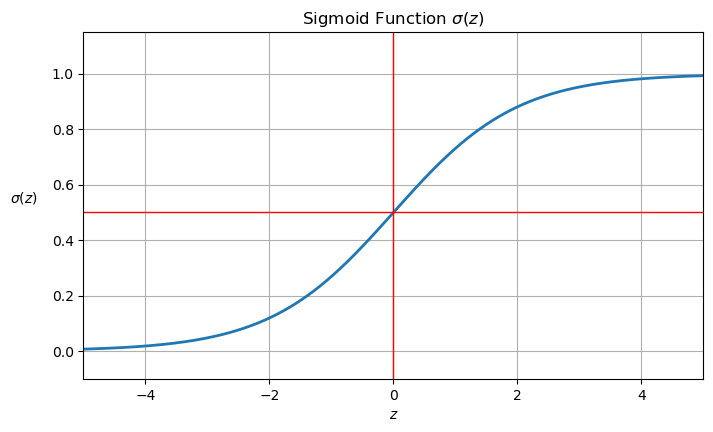

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
z = np.linspace(-5, 5, 500)

# Sigmoid function
sigma = 1 / (1 + np.exp(-z))

# Create plot
plt.figure(figsize=(8, 4.5))

# Plot sigmoid curve
plt.plot(z, sigma, linewidth=2)

# Reference lines
plt.axhline(0.5, color='red', linestyle='-', linewidth=1)
plt.axvline(0, color='red', linestyle='-', linewidth=1)

# Labels and title
plt.title(r"Sigmoid Function $\sigma(z)$")
plt.xlabel(r"$z$")
plt.ylabel(r"$\sigma(z)$",rotation=0, labelpad=20)

# Axis limits
plt.xlim(-5, 5)
plt.ylim(-0.1, 1.15)

# Grid
plt.grid(True)

plt.show()

$$
F_1 = \frac{2 \times \text{Precision} \times \text{Sensitivity}}
{\text{Precision} + \text{Sensitivity}}
$$


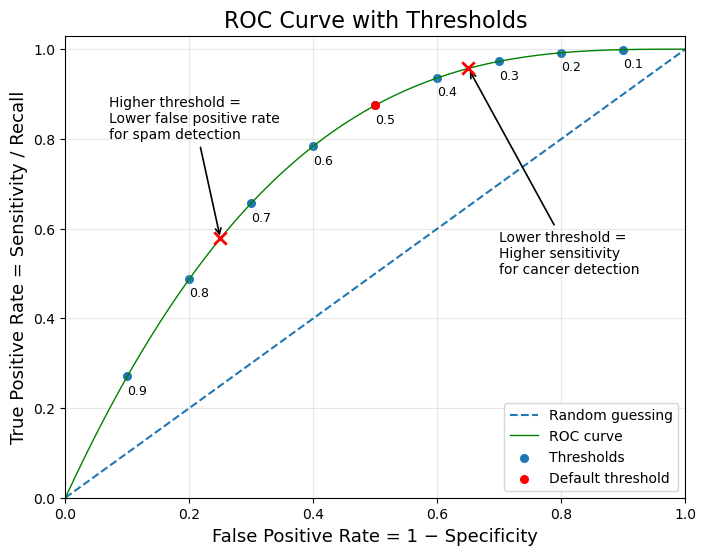

In [2]:
# ROC Curve with Threshold Points + Clean Legend + Adjusted Labels
import numpy as np
import matplotlib.pyplot as plt

# Smooth illustrative ROC curve
fpr = np.linspace(0, 1, 200)
tpr = 1 - (1 - fpr)**3

# Threshold values
thresholds = np.linspace(0.1, 0.9, 9)

# Index of default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))

# Map thresholds to ROC points
fpr_thresh = 1 - thresholds
tpr_thresh = 1 - (1 - fpr_thresh)**3

plt.figure(figsize=(8, 6))

# Random guessing
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guessing")

# ROC curve
plt.plot(fpr, tpr, linewidth=1, color='green',label="ROC curve")

# Threshold points (capture handle for legend)
threshold_scatter = plt.scatter(
    fpr_thresh, tpr_thresh,
    s=30,
    color='tab:blue',
    label="Thresholds"
)

# Highlight default threshold (0.5) in red
plt.scatter(
    fpr_thresh[default_idx],
    tpr_thresh[default_idx],
    color='red',
    s=30,
    zorder=6,
    label="Default threshold"
)

# Label thresholds (shift DOWN slightly)
for i, thr in enumerate(thresholds):
    plt.text(
        fpr_thresh[i] + 0.015,   # → shift right
        tpr_thresh[i] - 0.04,
        f"{thr:.1f}",
        fontsize=9,
        ha='center'
    )



# Custom illustrative thresholds (not on labeled points)
low_thresh = 0.35   # below 0.5 → more aggressive
high_thresh = 0.75  # above 0.5 → more conservative

# Map to ROC coordinates (same mapping as before)
low_fpr = 1 - low_thresh
low_tpr = 1 - (1 - low_fpr)**3

high_fpr = 1 - high_thresh
high_tpr = 1 - (1 - high_fpr)**3

cancer_point = (low_fpr, low_tpr)
conservative_point = (high_fpr, high_tpr)


# Plot example operating points as red X's
plt.scatter(
    *cancer_point,
    marker='x',
    s=80,
    linewidths=2,
    color='red',
    zorder=5
)

plt.scatter(
    *conservative_point,
    marker='x',
    s=80,
    linewidths=2,
    color='red',
    zorder=5
)

# Lower threshold label → move right
plt.annotate(
    "Lower threshold =\nHigher sensitivity\nfor cancer detection",
    xy=cancer_point,
    xytext=(0.70, 0.5),   # moved right
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10
)

# Higher threshold label → move to upper-left region
plt.annotate(
    "Higher threshold =\nLower false positive rate\nfor spam detection",
    xy=conservative_point,
    xytext=(0.07, 0.8),   # upper-left area
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10
)


# Formatting
plt.title("ROC Curve with Thresholds", fontsize=16)
plt.xlabel("False Positive Rate = 1 − Specificity", fontsize=13)
plt.ylabel("True Positive Rate = Sensitivity / Recall", fontsize=13)

plt.xlim(0, 1)
plt.ylim(0, 1.03)
plt.grid(alpha=0.3)

# Legend now includes thresholds automatically
plt.legend(loc="lower right")

plt.show()

### Week 6

In [1]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)

boston_data = boston.frame

print(boston_data.head())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


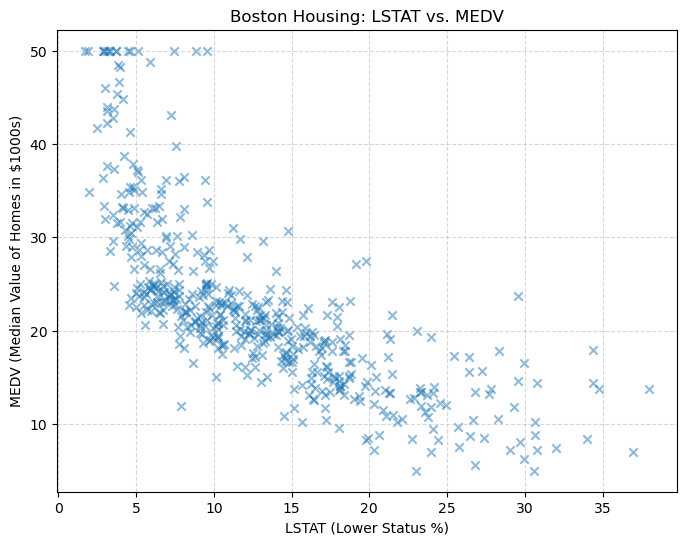

In [2]:
import matplotlib.pyplot as plt

# Scatterplot: LSTAT vs. MEDV
plt.figure(figsize=(8, 6))

plt.scatter(
    boston_data['LSTAT'],
    boston_data['MEDV'],
    alpha=0.5,
    marker='x'
)

plt.title('Boston Housing: LSTAT vs. MEDV')
plt.xlabel('LSTAT (Lower Status %)')
plt.ylabel('MEDV (Median Value of Homes in $1000s)')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

|--- LSTAT <= 9.72
|   |--- LSTAT <= 4.65
|   |   |--- LSTAT <= 3.32
|   |   |   |--- value: [43.99]
|   |   |--- LSTAT >  3.32
|   |   |   |--- value: [37.32]
|   |--- LSTAT >  4.65
|   |   |--- LSTAT <= 5.49
|   |   |   |--- value: [30.47]
|   |   |--- LSTAT >  5.49
|   |   |   |--- value: [25.85]
|--- LSTAT >  9.72
|   |--- LSTAT <= 16.09
|   |   |--- LSTAT <= 14.40
|   |   |   |--- value: [20.89]
|   |   |--- LSTAT >  14.40
|   |   |   |--- value: [18.31]
|   |--- LSTAT >  16.09
|   |   |--- LSTAT <= 19.90
|   |   |   |--- value: [16.37]
|   |   |--- LSTAT >  19.90
|   |   |   |--- value: [12.33]



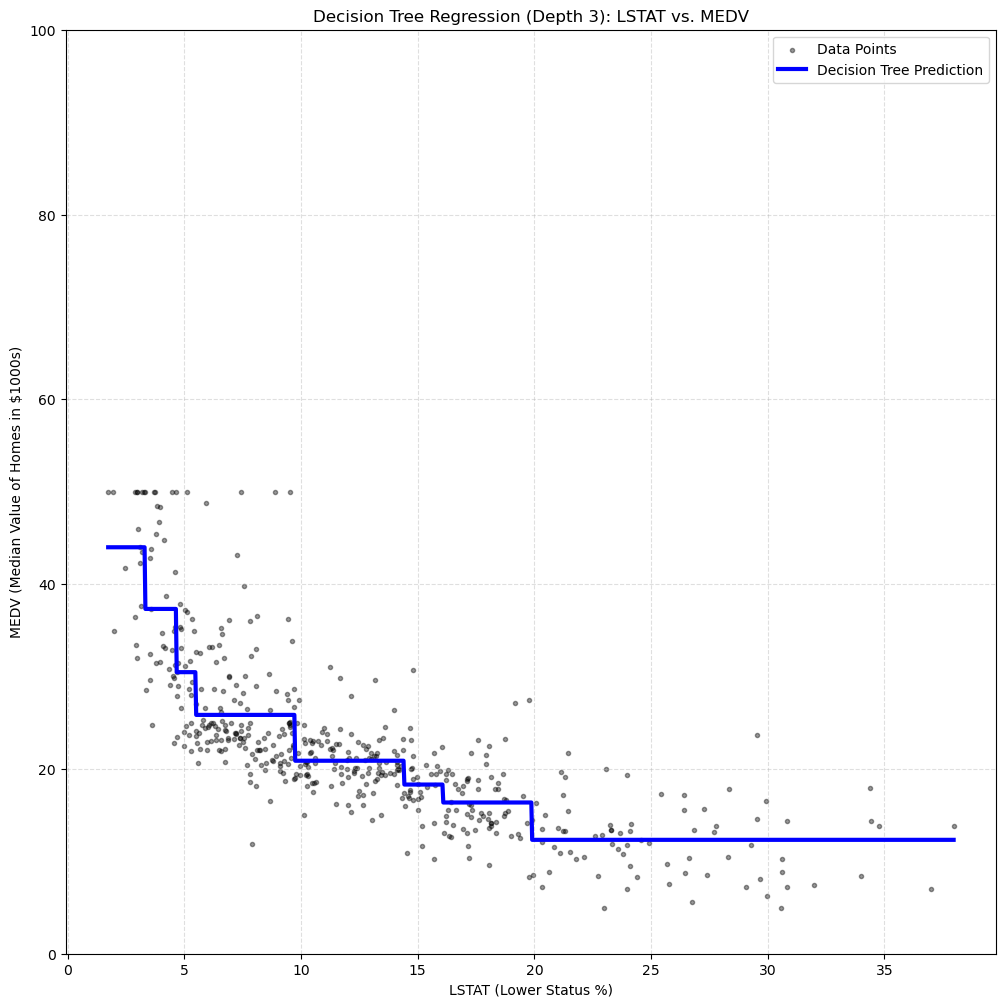

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

# Keep only the variables we need
X = boston_data[['LSTAT']].astype(float)
y = boston_data['MEDV'].astype(float)

# ------------------------------------------------------------
# Train regression decision tree
# ------------------------------------------------------------

depth = 3

model = DecisionTreeRegressor(
    max_depth=depth,
    random_state=42
)

model.fit(X, y)

# ------------------------------------------------------------
# Print the decision rules
# ------------------------------------------------------------

rules = export_text(
    model,
    feature_names=['LSTAT']
)

print(rules)

# ------------------------------------------------------------
# Generate smooth prediction curve
# ------------------------------------------------------------

x_grid = np.linspace(X['LSTAT'].min(), X['LSTAT'].max(), 1000)
X_grid = pd.DataFrame({'LSTAT': x_grid})

y_pred = model.predict(X_grid)

# ------------------------------------------------------------
# Extract split thresholds from the tree
# ------------------------------------------------------------

thresholds = model.tree_.threshold

# Remove invalid thresholds
split_points = sorted(
    [t for t in thresholds if t != -2]
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 12))

# Scatterplot
plt.scatter(
    X['LSTAT'],
    y,
    alpha=0.4,
    marker='.',
    color='black',
    label='Data Points'
)


    # Piecewise prediction function
plt.plot(
    x_grid,
    y_pred,
    color='blue',
    linewidth=3,
    label='Decision Tree Prediction'
)

# # Draw vertical split boundaries
# for split in split_points:
#     plt.axvline(
#         split,
#         color='red',
#         linestyle='--',
#         alpha=0.6
#     )

# Labels
plt.title(f'Decision Tree Regression (Depth {depth}): LSTAT vs. MEDV')
plt.xlabel('LSTAT (Lower Status %)')
plt.ylabel('MEDV (Median Value of Homes in $1000s)')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.ylim(0,100)

plt.show()

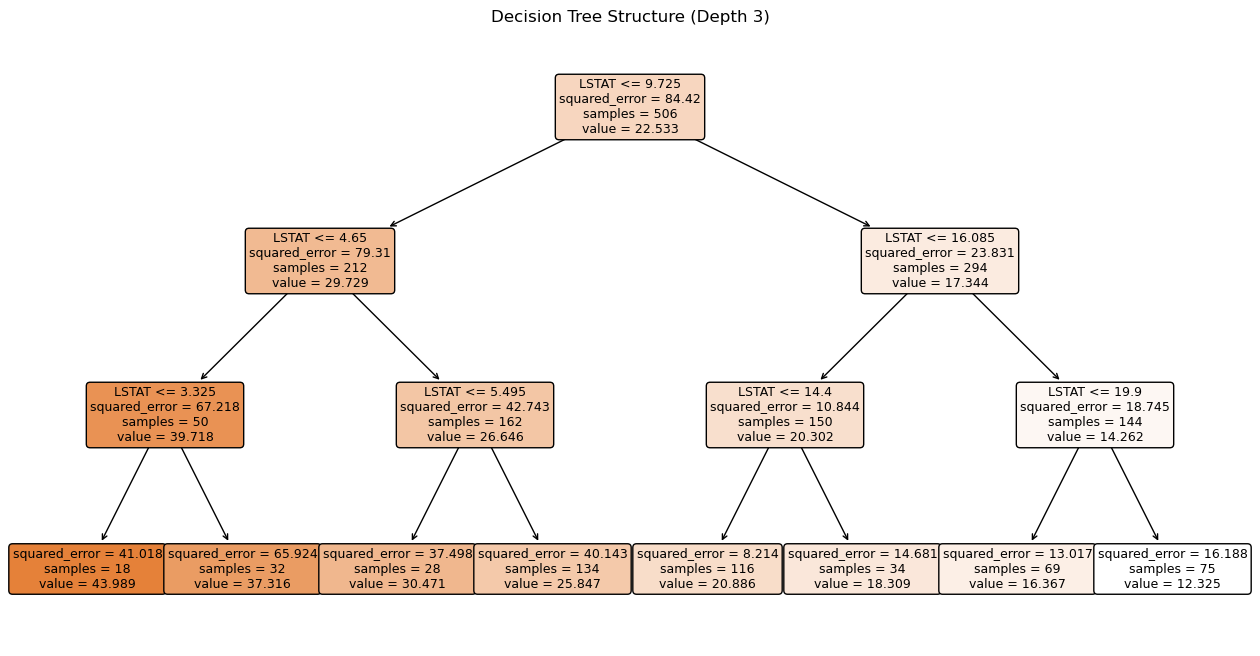

In [17]:
# ------------------------------------------------------------
# Display the tree diagram
# ------------------------------------------------------------

plt.figure(figsize=(16, 8))

plot_tree(
    model,
    feature_names=['LSTAT'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True
)

plt.title(f"Decision Tree Structure (Depth {depth})")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

# Keep only the variables we need
df = boston_data[['LSTAT', 'DIS', 'MEDV']].astype(float)

# ------------------------------------------------------------
# 3D scatterplot: LSTAT, DIS, MEDV
# ------------------------------------------------------------

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['LSTAT'],
    df['DIS'],
    df['MEDV'],
    alpha=0.7
)

ax.set_xlabel('LSTAT',labelpad=10)
ax.set_ylabel('DIS',labelpad=10)
ax.set_zlabel('MEDV',labelpad=18)

ax.set_title('Boston Housing Dataset: MEDV by LSTAT and DIS')

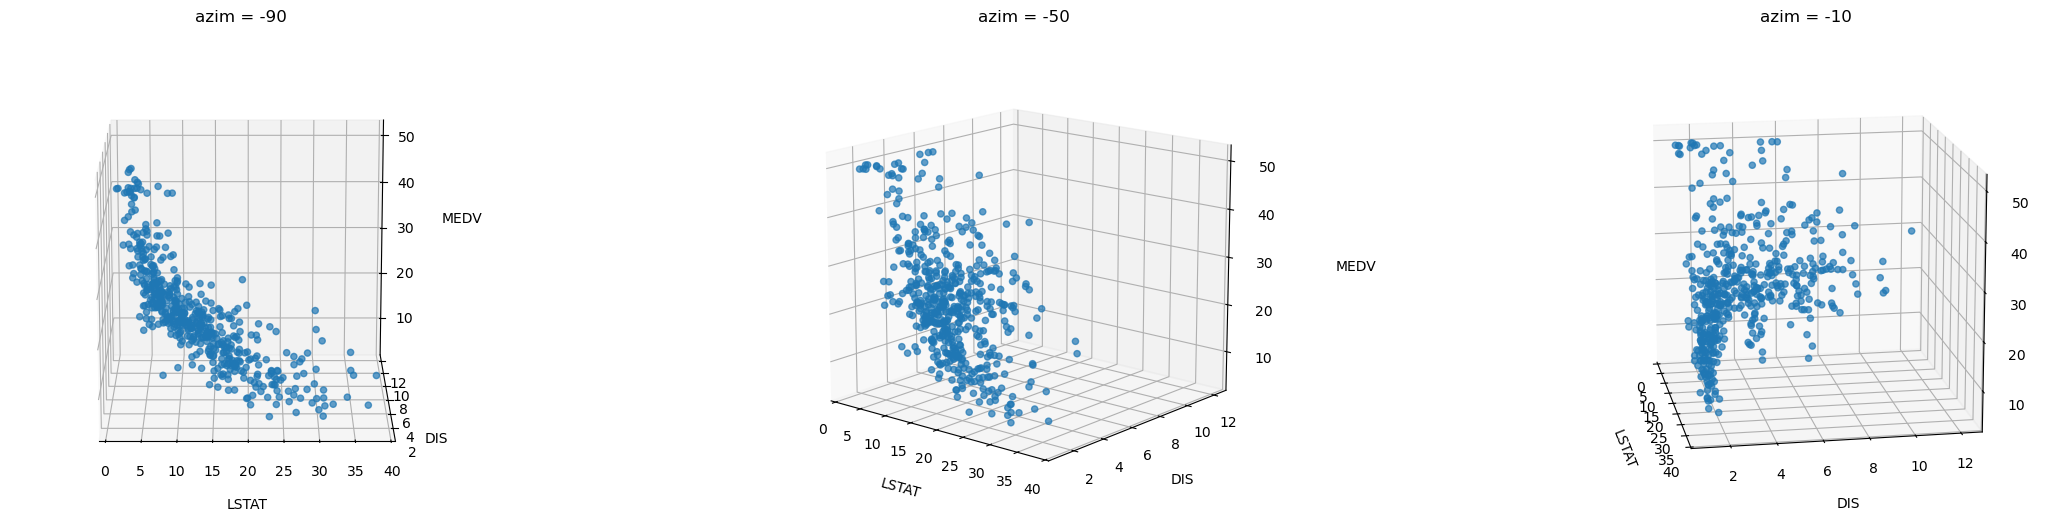

In [51]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)

df = boston.frame[['LSTAT', 'DIS', 'MEDV']].astype(float)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(26, 6))

# Extra spacing and right margin
fig.subplots_adjust(
    wspace=0.35,
    right=0.95
)

# ------------------------------------------------------------
# Three viewing angles
# ------------------------------------------------------------

angles = [-90, -50, -10]

for i, az in enumerate(angles, start=1):

    ax = fig.add_subplot(1, 3, i, projection='3d')

    # Scatter plot
    ax.scatter(
        df['LSTAT'],
        df['DIS'],
        df['MEDV'],
        alpha=0.7
    )

    # Axis labels
    ax.set_xlabel('LSTAT', labelpad=10)
    ax.set_ylabel('DIS', labelpad=10)
    ax.set_zlabel('MEDV', labelpad=35)

    # Extra spacing for z-axis ticks
    ax.tick_params(axis='z', pad=8)

    # Slightly shrink 3D box
    ax.set_box_aspect((1, 1, 0.9))

    # Viewing angle
    ax.view_init(
        elev=15,
        azim=az
    )

    # Title
    ax.set_title(
        f'azim = {az}',
        pad=20
    )

plt.show()



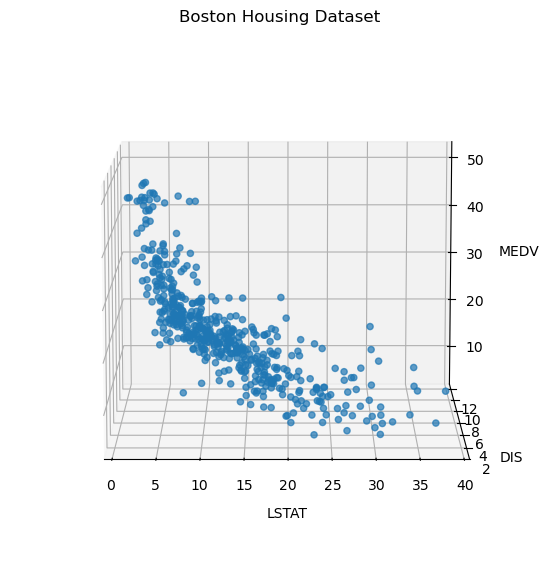

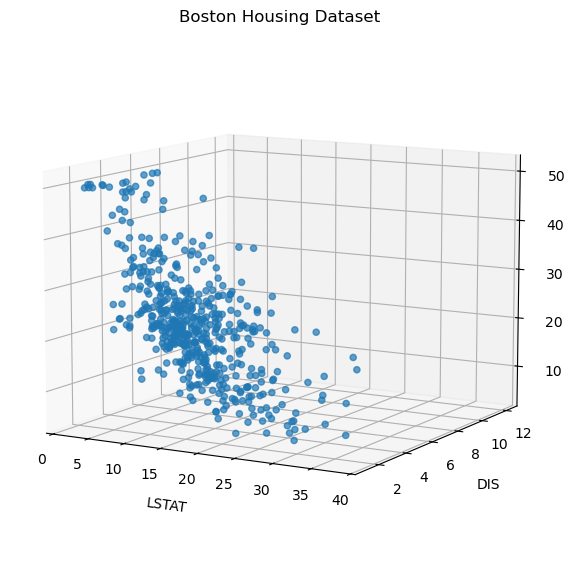

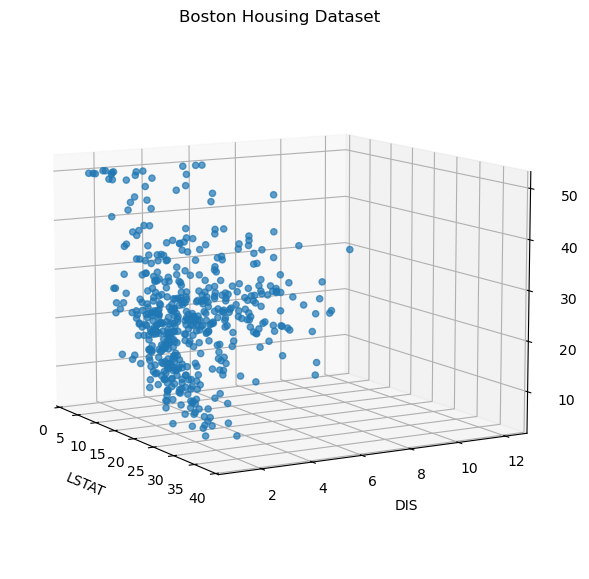

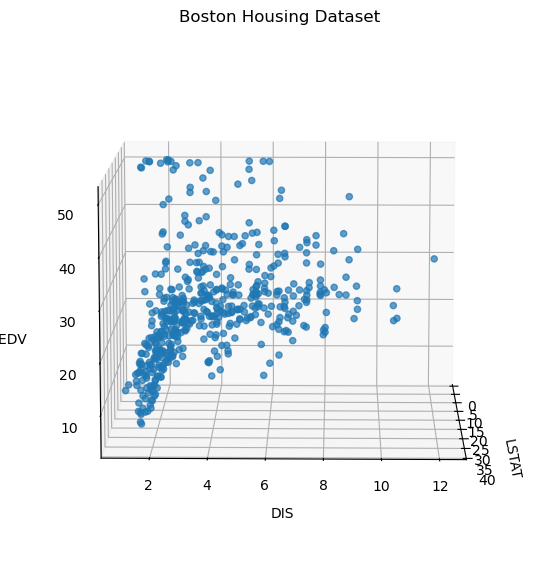

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

# Keep only the variables we need
df = boston_data[['LSTAT', 'DIS', 'MEDV']].astype(float)

# ------------------------------------------------------------
# Create three separate plots
# ------------------------------------------------------------

angles = [-90, -60, -30, 1]

for az in angles:

    fig = plt.figure(figsize=(10, 7))

    # Create 3D axes
    ax = plt.axes(projection='3d')

    # Scatter plot
    ax.scatter(
        df['LSTAT'],
        df['DIS'],
        df['MEDV'],
        alpha=0.7
    )

    # Labels
    ax.set_xlabel('LSTAT', labelpad=10)
    ax.set_ylabel('DIS', labelpad=10)
    ax.set_zlabel('MEDV', labelpad=25)

    # Add spacing for z ticks
    ax.tick_params(axis='z', pad=8)

    # Viewing angle
    ax.view_init(
        elev=10,
        azim=az
    )

    # Title
    ax.set_title(
        f'Boston Housing Dataset'
    )

    plt.show()

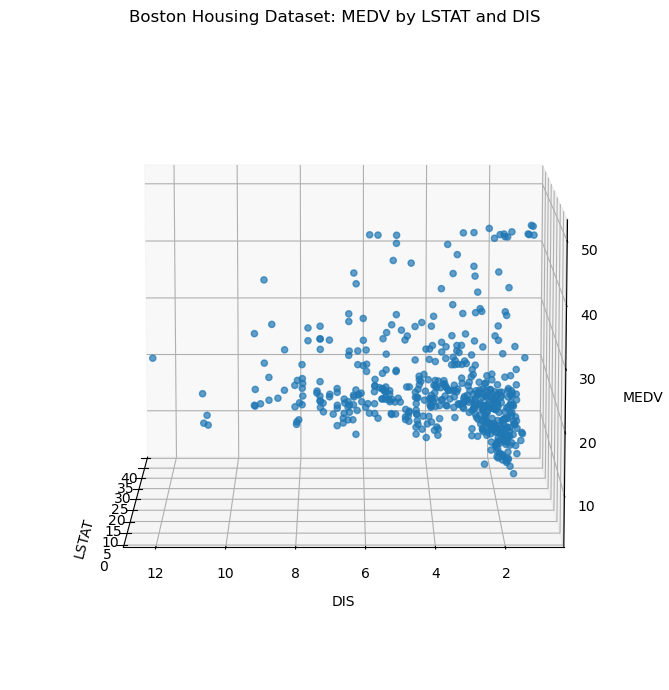

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

# Keep only the variables we need
df = boston_data[['LSTAT', 'DIS', 'MEDV']].astype(float)

# ------------------------------------------------------------
# 3D scatterplot: LSTAT, DIS, MEDV
# ------------------------------------------------------------

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['LSTAT'],
    df['DIS'],
    df['MEDV'],
    alpha=0.7
)

ax.set_xlabel('LSTAT',labelpad=10)
ax.set_ylabel('DIS',labelpad=10)
ax.set_zlabel('MEDV',labelpad=18)

ax.set_title('Boston Housing Dataset: MEDV by LSTAT and DIS')

# Optional: adjust viewing angle
ax.view_init(elev=10, azim=180)

plt.tight_layout()
plt.show()

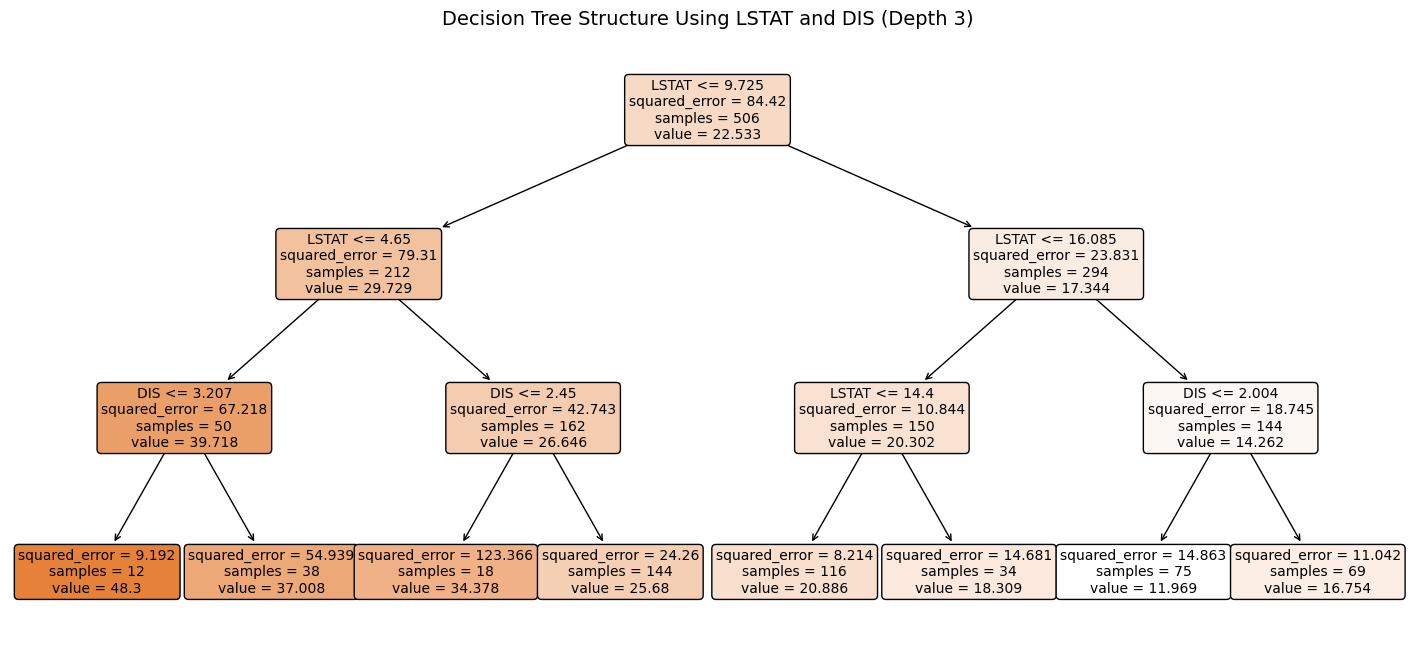

In [62]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeRegressor, plot_tree

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

# Features and target
X = boston_data[['LSTAT', 'DIS']].astype(float)
y = boston_data['MEDV'].astype(float)

# ------------------------------------------------------------
# Train decision tree regressor
# ------------------------------------------------------------

tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree.fit(X, y)

# ------------------------------------------------------------
# Plot decision tree
# ------------------------------------------------------------

plt.figure(figsize=(18, 8))

plot_tree(
    tree,
    feature_names=['LSTAT', 'DIS'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Decision Tree Structure Using LSTAT and DIS (Depth 3)', fontsize=14)
plt.show()



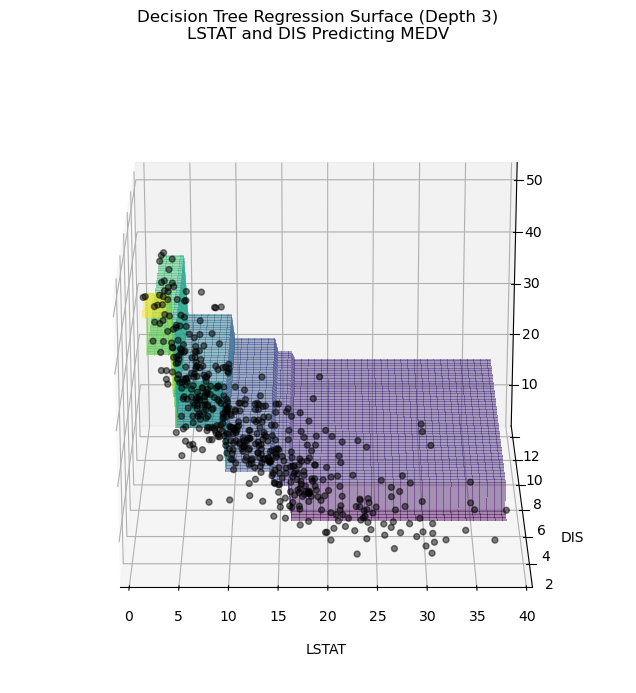

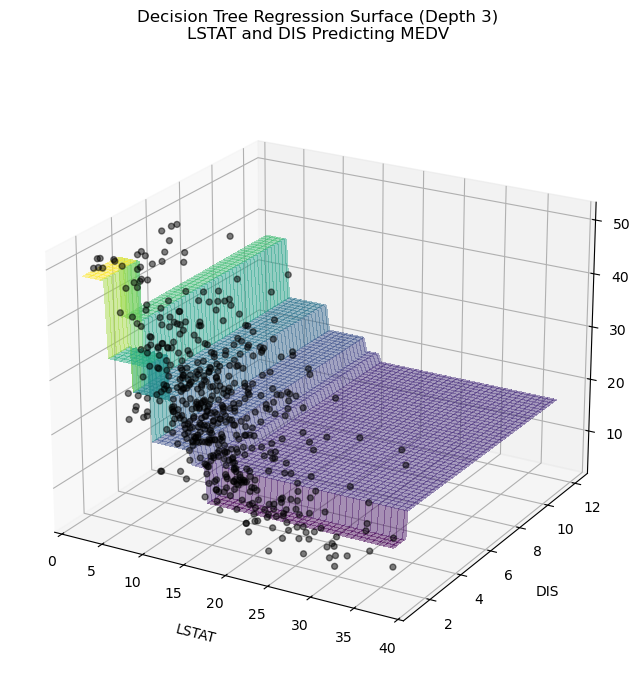

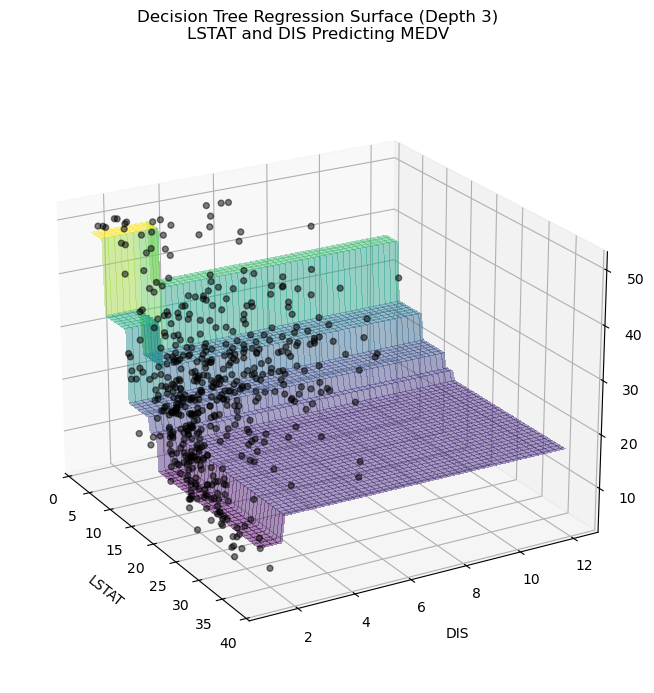

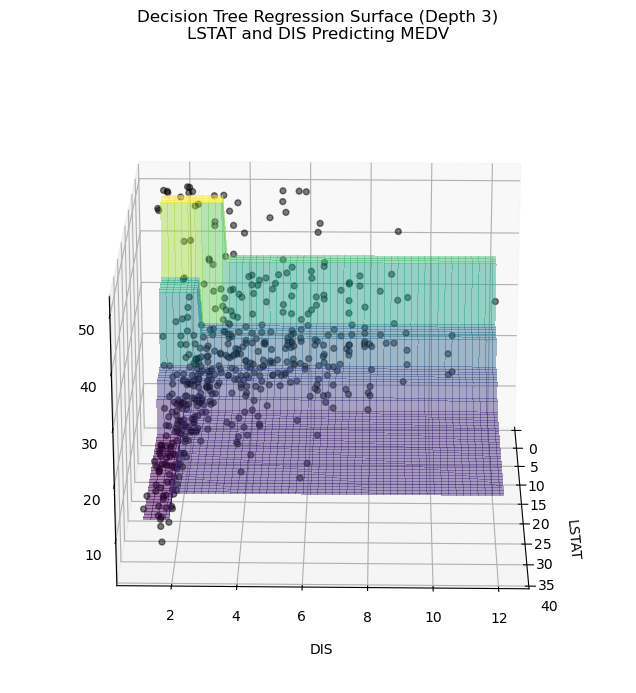

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeRegressor

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

X = boston_data[['LSTAT', 'DIS']].astype(float)
y = boston_data['MEDV'].astype(float)

# ------------------------------------------------------------
# Train decision tree
# ------------------------------------------------------------

tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree.fit(X, y)

# ------------------------------------------------------------
# Create prediction grid
# ------------------------------------------------------------

lstat_grid = np.linspace(X['LSTAT'].min(), X['LSTAT'].max(), 100)
dis_grid = np.linspace(X['DIS'].min(), X['DIS'].max(), 100)

LSTAT_grid, DIS_grid = np.meshgrid(lstat_grid, dis_grid)

grid_points = pd.DataFrame({
    'LSTAT': LSTAT_grid.ravel(),
    'DIS': DIS_grid.ravel()
})

MEDV_pred = tree.predict(grid_points).reshape(LSTAT_grid.shape)

angles = [-90, -60, -30, 1]

for az in angles:

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    
    fig = plt.figure(figsize=(11, 8))
    ax = plt.axes(projection='3d')
    
    # Original data points
    ax.scatter(
        X['LSTAT'],
        X['DIS'],
        y,
        color='black',
        alpha=0.5,
        s=18
    )
    
    
    ax.plot_surface(
        LSTAT_grid,
        DIS_grid,
        MEDV_pred,
        alpha=0.45,
        cmap='viridis',
        edgecolor='none',
        linewidth=0,
        antialiased=False,
    )
    
    # ------------------------------------------------------------
    # Labels and view
    # ------------------------------------------------------------
    
    ax.set_xlabel('LSTAT', labelpad=10)
    ax.set_ylabel('DIS', labelpad=10)
    
    
    ax.set_title(
        'Decision Tree Regression Surface (Depth 3)\nLSTAT and DIS Predicting MEDV',
        pad=20
    )
    
    ax.view_init(elev=22, azim=az)
    
    plt.show()

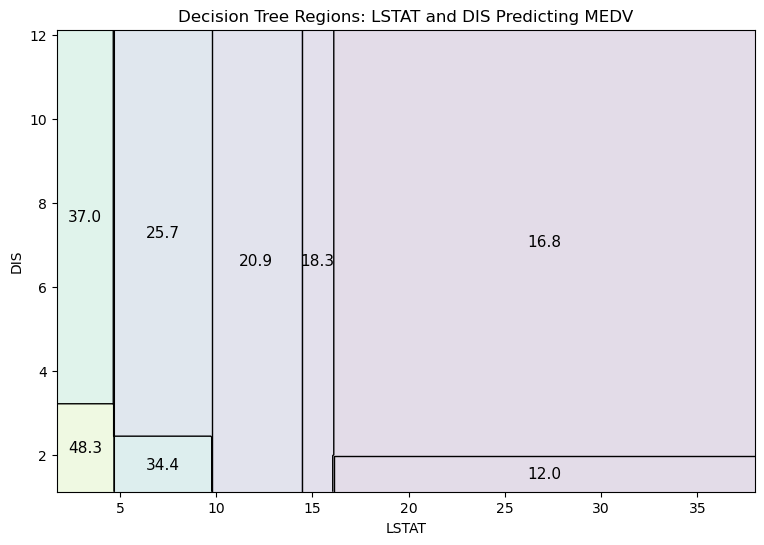

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeRegressor

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

X = boston_data[['LSTAT', 'DIS']].astype(float)
y = boston_data['MEDV'].astype(float)

# ------------------------------------------------------------
# Train decision tree
# ------------------------------------------------------------

tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree.fit(X, y)

# ------------------------------------------------------------
# Create grid and predict regions
# ------------------------------------------------------------

x_min, x_max = X['LSTAT'].min(), X['LSTAT'].max()
y_min, y_max = X['DIS'].min(), X['DIS'].max()

lstat_grid = np.linspace(x_min, x_max, 500)
dis_grid = np.linspace(y_min, y_max, 500)

LSTAT_grid, DIS_grid = np.meshgrid(lstat_grid, dis_grid)

grid_points = pd.DataFrame({
    'LSTAT': LSTAT_grid.ravel(),
    'DIS': DIS_grid.ravel()
})

pred_grid = tree.predict(grid_points).reshape(LSTAT_grid.shape)

# ------------------------------------------------------------
# Plot rectangular decision regions
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.contourf(
    LSTAT_grid,
    DIS_grid,
    pred_grid,
    levels=np.unique(pred_grid),
    alpha=0.15
)

plt.contour(
    LSTAT_grid,
    DIS_grid,
    pred_grid,
    levels=np.unique(pred_grid),
    colors='black',
    linewidths=1
)

# ------------------------------------------------------------
# Label each region with its predicted value
# ------------------------------------------------------------

leaf_ids = tree.apply(grid_points)

for leaf in np.unique(leaf_ids):

    mask = leaf_ids.reshape(LSTAT_grid.shape) == leaf

    x_center = LSTAT_grid[mask].mean()
    y_center = DIS_grid[mask].mean()
    pred_value = pred_grid[mask][0]

    plt.text(
        x_center,
        y_center,
        f'{pred_value:.1f}',
        ha='center',
        va='center',
        fontsize=11
    )

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

plt.xlabel('LSTAT')
plt.ylabel('DIS')
plt.title('Decision Tree Regions: LSTAT and DIS Predicting MEDV')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.show()

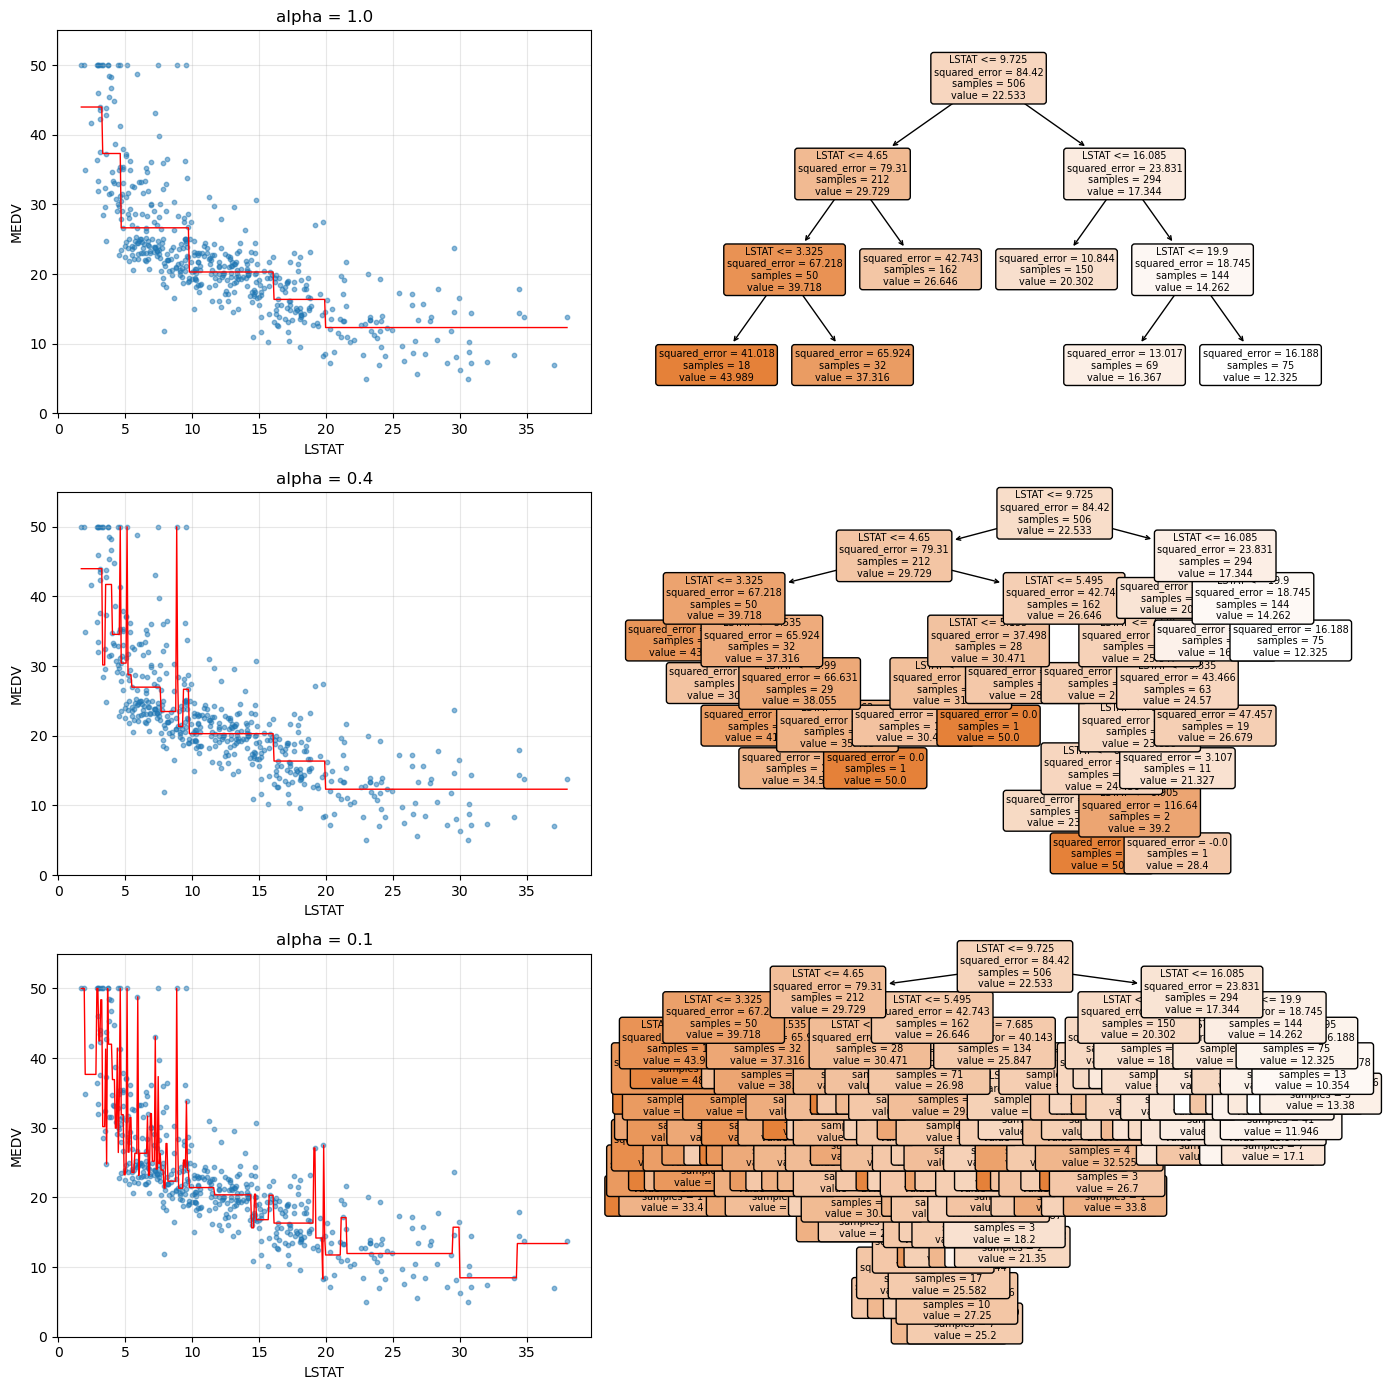

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeRegressor, plot_tree

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

X = boston_data[['LSTAT']].astype(float)
y = boston_data['MEDV'].astype(float)

# ------------------------------------------------------------
# Alpha values to compare
# ------------------------------------------------------------

alphas = [1.0, 0.4, 0.1]

# Grid for plotting prediction curve
x_grid = np.linspace(X['LSTAT'].min(), X['LSTAT'].max(), 500).reshape(-1, 1)
x_grid_df = pd.DataFrame(x_grid, columns=['LSTAT'])

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=len(alphas),
    ncols=2,
    figsize=(14, 14),
    gridspec_kw={'width_ratios': [1.1, 1.4]}
)

for row, alpha in enumerate(alphas):

    # --------------------------------------------------------
    # Train pruned decision tree
    # --------------------------------------------------------

    tree = DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=alpha
    )

    tree.fit(X, y)

    y_pred = tree.predict(x_grid_df)

    # --------------------------------------------------------
    # Left plot: scatterplot + prediction function
    # --------------------------------------------------------

    ax_scatter = axes[row, 0]

    ax_scatter.scatter(
        X['LSTAT'],
        y,
        s=10,
        alpha=0.5
    )

    ax_scatter.plot(
        x_grid,
        y_pred,
        color='red',
        linewidth=1.0
    )

    ax_scatter.set_title(f'alpha = {alpha}')
    ax_scatter.set_xlabel('LSTAT')
    ax_scatter.set_ylabel('MEDV')

    ax_scatter.set_ylim(0, 55)
    ax_scatter.grid(True, alpha=0.3)

    # --------------------------------------------------------
    # Right plot: tree structure
    # --------------------------------------------------------

    ax_tree = axes[row, 1]

    plot_tree(
        tree,
        feature_names=['LSTAT'],
        filled=True,
        rounded=True,
        fontsize=7,
        ax=ax_tree
    )

    # ax_tree.set_title(f'Tree Structure')

plt.tight_layout()
plt.show()

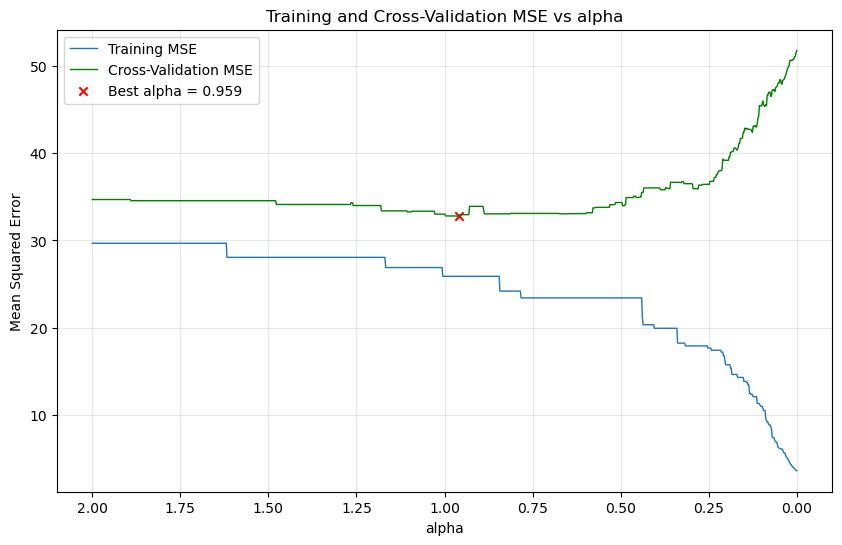

Best alpha: 0.9590
Best cross-validation MSE: 32.7834


In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# Load Boston Housing dataset
# ------------------------------------------------------------

boston = fetch_openml(name="boston", version=1, as_frame=True)
boston_data = boston.frame

X = boston_data[['LSTAT']].astype(float)
y = boston_data['MEDV'].astype(float)

# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# Alpha values to test
# ------------------------------------------------------------

alpha_values = np.linspace(0.0, 2.0, 1000)

train_mse_values = []
cv_mse_values = []

# ------------------------------------------------------------
# Evaluate training MSE and cross-validation MSE
# ------------------------------------------------------------

for alpha in alpha_values:

    tree = DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=alpha
    )

    # Training MSE
    tree.fit(X_train, y_train)
    y_train_pred = tree.predict(X_train)

    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    train_mse_values.append(train_mse)

    # Cross-validation MSE
    cv_scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    cv_mse = -cv_scores.mean()
    cv_mse_values.append(cv_mse)

# ------------------------------------------------------------
# Find best alpha by CV MSE
# ------------------------------------------------------------

best_index = np.argmin(cv_mse_values)
best_alpha = alpha_values[best_index]
best_cv_mse = cv_mse_values[best_index]

# ------------------------------------------------------------
# Plot validation curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    alpha_values,
    train_mse_values,
    label='Training MSE',
    linewidth=1
)

plt.plot(
    alpha_values,
    cv_mse_values,
    color='green',
    label='Cross-Validation MSE',
    linewidth=1
)

# plt.scatter(
#     best_alpha,
#     best_cv_mse,
#     marker='o',
#     s=50,
#     zorder=5,
#     color='red',
#     linewidth=1,
#     label=f'Best alpha = {best_alpha:.3f}'
# )

plt.scatter(
    best_alpha,
    best_cv_mse,
    marker='x',
    color='red',
    label=f'Best alpha = {best_alpha:.3f}'
)

plt.xlabel('alpha')
plt.ylabel('Mean Squared Error')
plt.title('Training and Cross-Validation MSE vs alpha')

plt.grid(True, alpha=0.3)
plt.legend()

# Reverse alpha axis
plt.gca().invert_xaxis()

plt.show()

print(f'Best alpha: {best_alpha:.4f}')
print(f'Best cross-validation MSE: {best_cv_mse:.4f}')

### Week 7

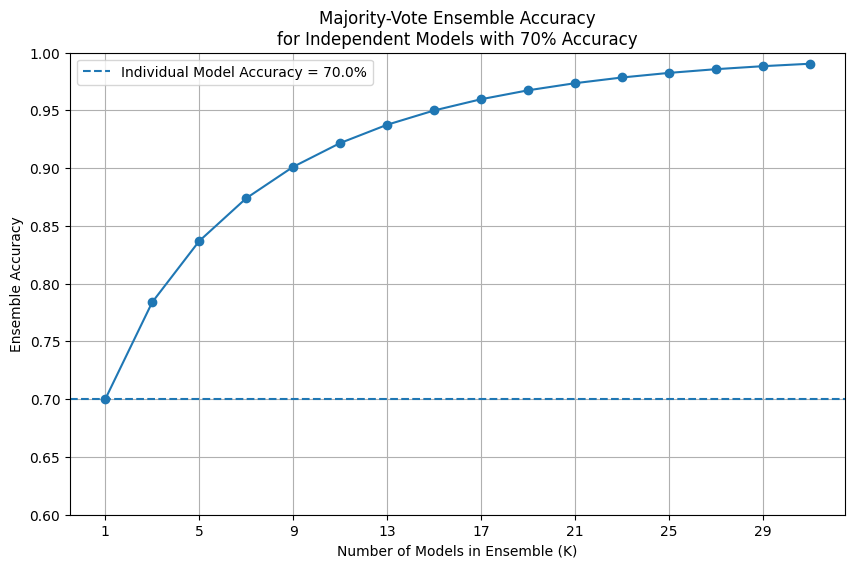

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

p = 0.7                    # accuracy of each individual model
K_values = range(1, 32, 2)  # odd numbers from 1 to 51

# ------------------------------------------------------------
# Majority-vote ensemble accuracy
# ------------------------------------------------------------

ensemble_accuracies = []

for K in K_values:

    # Need strictly more than half the votes correct
    min_correct = K // 2 + 1

    acc = 0

    # Binomial probability of majority being correct
    for i in range(min_correct, K + 1):
        acc += comb(K, i) * (p ** i) * ((1 - p) ** (K - i))

    ensemble_accuracies.append(acc)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.plot(
    K_values,
    ensemble_accuracies,
    marker='o'
)

# Individual model accuracy baseline
plt.axhline(
    y=p,
    linestyle='--',
    label=f'Individual Model Accuracy = {p:.1%}'
)

plt.xlabel("Number of Models in Ensemble (K)")
plt.ylabel("Ensemble Accuracy")
plt.title("Majority-Vote Ensemble Accuracy\nfor Independent Models with 70% Accuracy")

plt.xticks(K_values[::2])  # label every other odd value
plt.ylim(0.60, 1.0)

plt.grid(True)
plt.legend()

plt.show()

In [12]:
for k in range(len(ensemble_accuracies)):
    print(K_values[k],ensemble_accuracies[k])

1 0.7
3 0.7839999999999999
5 0.8369199999999999
7 0.873964
9 0.90119134
11 0.92177520904
13 0.9376247882008
15 0.9499874599462239
17 0.9597230639457454
19 0.967446643118699
21 0.9736100592987161
23 0.978551998453966
25 0.9825302594739422
27 0.9857434702977693
29 0.9883461710650691
31 0.9904595640881165


In [8]:
import numpy as np
import pandas as pd

from scipy.stats import mode

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Load Wisconsin Breast Cancer dataset
# ------------------------------------------------------------

data = load_breast_cancer()

X = data.data
y = data.target

# ------------------------------------------------------------
# Train / test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Create intentionally weaker models
# ------------------------------------------------------------

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            C=0.05
        )
    ),

    "k-NN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(
            n_neighbors=21
        )
    ),

    "SVM": make_pipeline(
        StandardScaler(),
        SVC(
            kernel="linear",
            C=0.05
        )
    )
}

# ------------------------------------------------------------
# Train models and collect predictions
# ------------------------------------------------------------

predictions = []
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    predictions.append(y_pred)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

# ------------------------------------------------------------
# Majority voting ensemble
# ------------------------------------------------------------

predictions = np.array(predictions)

ensemble_pred = mode(
    predictions,
    axis=0,
    keepdims=False
).mode

ensemble_acc = accuracy_score(y_test, ensemble_pred)

results.append({
    "Model": "Majority Vote Ensemble",
    "Accuracy": ensemble_acc
})

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print(results_df)

                    Model  Accuracy
0     Logistic Regression  0.959064
1                    k-NN  0.947368
2                     SVM  0.970760
3  Majority Vote Ensemble  0.953216


#### Week 8

$$
\mathrm{WCSS}
=
\sum_{j=1}^{k}
\sum_{x_i \in C_j}
\left\| x_i - \mu_j \right\|^2
$$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


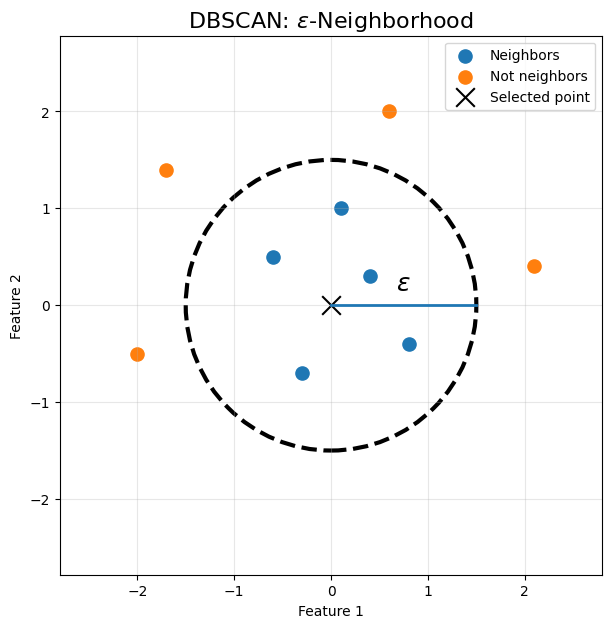

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Reproducibility
np.random.seed(42)

# Parameters
epsilon = 1.5
center = np.array([0, 0])

# Create example points
inside_points = np.array([
    [0.4, 0.3],
    [-0.6, 0.5],
    [0.8, -0.4],
    [-0.3, -0.7],
    [0.1, 1.0],
])

outside_points = np.array([
    [2.1, 0.4],
    [-2.0, -0.5],
    [0.6, 2.0],
    [-1.7, 1.4],
])

# Plot
plt.figure(figsize=(7, 7))
ax = plt.gca()

# Epsilon neighborhood circle
circle = Circle(center, epsilon, fill=False, linewidth=3, linestyle="--")
ax.add_patch(circle)

# Points
plt.scatter(inside_points[:, 0], inside_points[:, 1], s=90, label="Neighbors")
plt.scatter(outside_points[:, 0], outside_points[:, 1], s=90, label="Not neighbors")
plt.scatter(center[0], center[1], s=180, marker="x", color='black',label="Selected point")

# Radius line
plt.plot([center[0], epsilon], [center[1], 0], linewidth=2)
plt.text(epsilon / 2, 0.15, r"$\varepsilon$", fontsize=18, ha="center")

# Labels and formatting
plt.title(r"DBSCAN: $\varepsilon$-Neighborhood", fontsize=16)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plt.xlim(-2.8, 2.8)
plt.ylim(-2.8, 2.8)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.show()

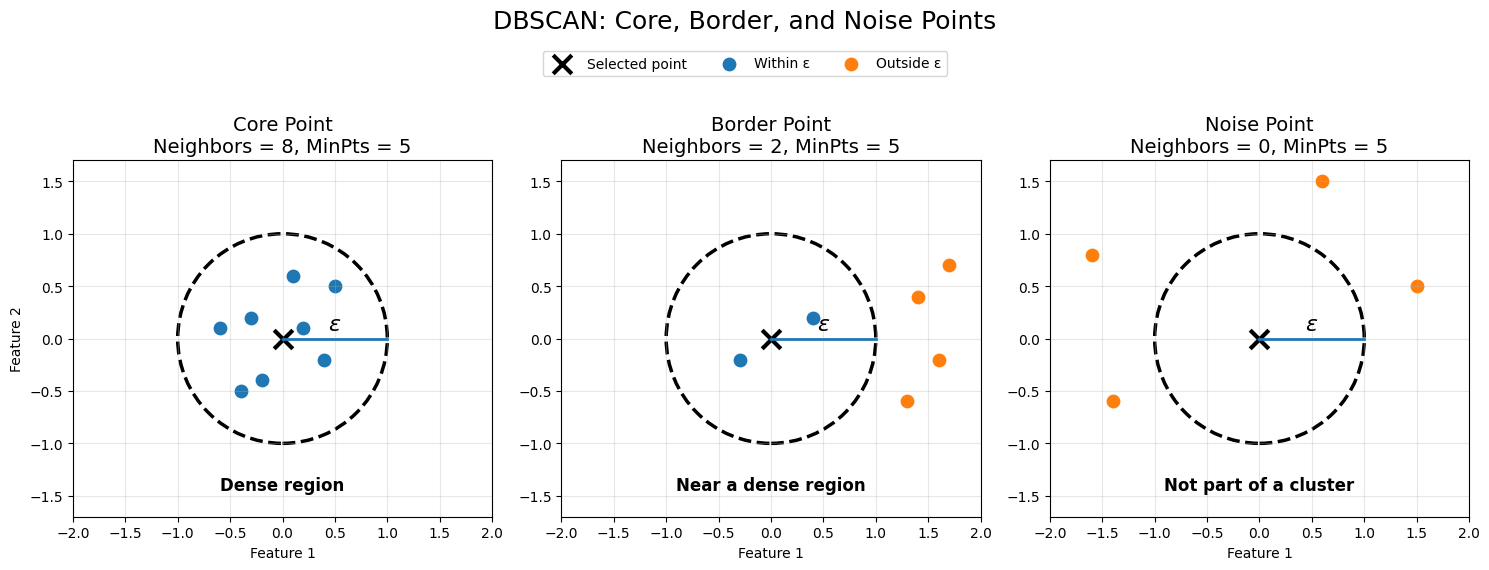

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Parameters
epsilon = 1.0
min_pts = 5

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    {
        "title": "Core Point",
        "subtitle": "Neighbors = 8",
        "center": (0, 0),
        "points": [
            (0.2, 0.1), (-0.3, 0.2), (0.4, -0.2), (-0.2, -0.4),
            (0.1, 0.6), (-0.6, 0.1), (0.5, 0.5), (-0.4, -0.5)
        ],
        "status": "Dense region",
    },
    {
        "title": "Border Point",
        "subtitle": "Neighbors = 2",
        "center": (0, 0),
        "points": [
            (0.4, 0.2), (-0.3, -0.2),    # inside epsilon
            (1.4, 0.4), (1.6, -0.2), (1.7, 0.7), (1.3, -0.6)
        ],
        "status": "Near a dense region",
    },
    {
        "title": "Noise Point",
        "subtitle": "Neighbors = 0",
        "center": (0, 0),
        "points": [
            (1.5, 0.5), (-1.4, -0.6), (0.6, 1.5), (-1.6, 0.8)
        ],
        "status": "Not part of a cluster",
    },
]

for ax, panel in zip(axes, panels):
    center = np.array(panel["center"])
    points = np.array(panel["points"])

    # Epsilon neighborhood
    circle = Circle(
        center,
        epsilon,
        fill=False,
        linestyle="--",
        linewidth=2.5,
        color="black"
    )
    ax.add_patch(circle)

    # Selected point
    ax.scatter(
        center[0],
        center[1],
        s=180,
        marker="x",
        color="black",
        linewidths=3,
        label="Selected point"
    )

    # Other points
    distances = np.linalg.norm(points - center, axis=1)
    inside = distances <= epsilon

    ax.scatter(
        points[inside, 0],
        points[inside, 1],
        s=80,
        label="Within ε"
    )

    ax.scatter(
        points[~inside, 0],
        points[~inside, 1],
        s=80,
        label="Outside ε"
    )

    # Radius label
    ax.plot([0, epsilon], [0, 0], linewidth=2)
    ax.text(epsilon / 2, 0.08, r"$\varepsilon$", fontsize=16, ha="center")

    # Titles and annotation
    ax.set_title(f"{panel['title']}\n{panel['subtitle']}, MinPts = {min_pts}", fontsize=14)
    ax.text(
        0,
        -1.45,
        panel["status"],
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    # Axes formatting
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.7, 1.7)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Feature 1")

axes[0].set_ylabel("Feature 2")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05))

fig.suptitle("DBSCAN: Core, Border, and Noise Points", fontsize=18, y=1.12)
plt.tight_layout()
plt.show()

| Method | Need to Specify Number of Clusters? | Handles Irregular Shapes? | Detects Outliers? |
|----------|------------------------------------|---------------------------|-------------------|
| K-Means | Yes | No | No |
| Hierarchical Clustering | No | Sometimes | No |
| DBSCAN | No | Yes | Yes |

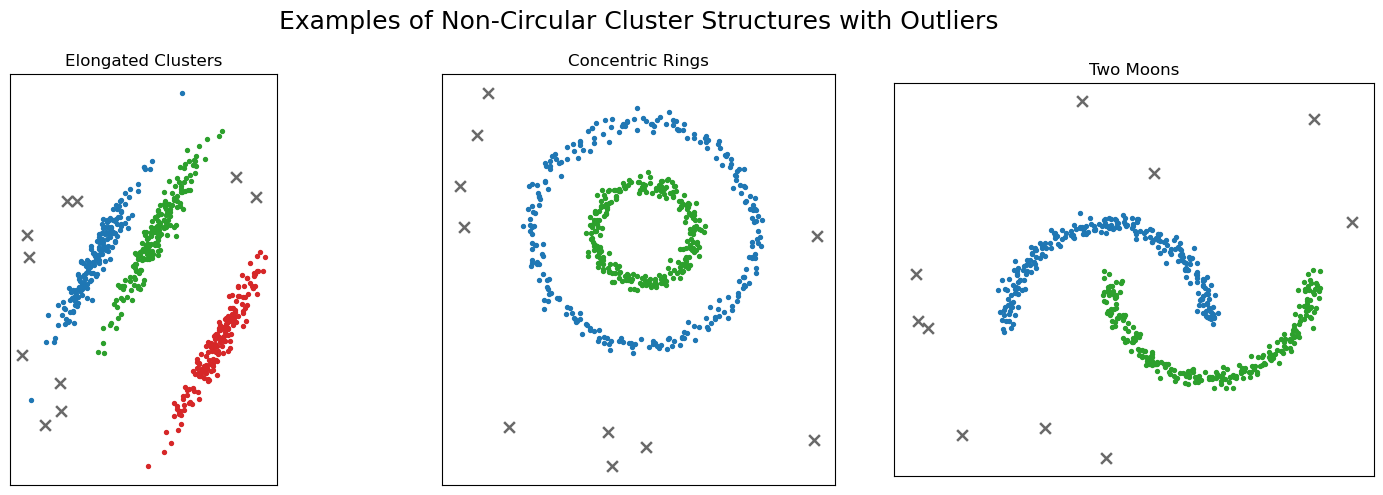

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles, make_moons


# ------------------------------------------------------------
# Create outliers that are far from existing data points
# ------------------------------------------------------------

def create_outliers_away_from_data(
    X,
    n_outliers=10,
    low=-2.3,
    high=2.3,
    min_distance=0.35,
    seed=42
):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)

        distances = np.linalg.norm(X - p, axis=1)

        if distances.min() > min_distance:
            outliers.append(p)

    return np.array(outliers)


# ------------------------------------------------------------
# Create outliers outside circular clusters
# ------------------------------------------------------------

def create_ring_outliers(
    n_outliers=10,
    low=-2.3,
    high=2.3,
    min_radius=1.55,
    seed=42
):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)

        if np.linalg.norm(p) > min_radius:
            outliers.append(p)

    return np.array(outliers)


# ------------------------------------------------------------
# Create elongated parallel clusters
# ------------------------------------------------------------

def make_elongated_clusters(seed=42):

    rng = np.random.RandomState(seed)

    centers = [
        [-0.8,  0.6],
        [ 0.0,  0.9],
        [ 0.8, -0.6]
    ]

    X_all = []
    y_all = []

    for i, center in enumerate(centers):

        n = 180

        x = rng.normal(0, 0.08, size=n)
        y = rng.normal(0, 0.65, size=n)

        X = np.column_stack([x, y])

        theta = np.deg2rad(-28)

        R = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta),  np.cos(theta)]
        ])

        X = X @ R.T
        X = X + np.array(center)

        X_all.append(X)
        y_all.append(np.full(n, i))

    return np.vstack(X_all), np.concatenate(y_all)


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

n_outliers = 10

point_size = 8
outlier_size = 60

blue  = "#1f77b4"
green = "#2ca02c"
red   = "#d62728"
gray  = "dimgray"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# ============================================================
# 1. Elongated Clusters
# ============================================================

X, y = make_elongated_clusters(seed=42)

outliers = create_outliers_away_from_data(
    X,
    n_outliers=n_outliers,
    low=-1.8,
    high=1.8,
    min_distance=0.35,
    seed=1
)

cluster_colors = [blue, green, red]

for i in range(3):
    axes[0].scatter(
        X[y == i, 0],
        X[y == i, 1],
        color=cluster_colors[i],
        s=point_size
    )

axes[0].scatter(
    outliers[:, 0],
    outliers[:, 1],
    color=gray,
    marker="x",
    s=outlier_size,
    linewidths=1.8
)

axes[0].set_title("Elongated Clusters")
axes[0].set_aspect("equal")


# ============================================================
# 2. Concentric Rings
# ============================================================

X, y = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.04,
    random_state=42
)

outliers = create_ring_outliers(
    n_outliers=n_outliers,
    low=-2.2,
    high=2.2,
    min_radius=1.55,
    seed=2
)

cluster_colors = [blue, green]

for i in range(2):
    axes[1].scatter(
        X[y == i, 0],
        X[y == i, 1],
        color=cluster_colors[i],
        s=point_size
    )

axes[1].scatter(
    outliers[:, 0],
    outliers[:, 1],
    color=gray,
    marker="x",
    s=outlier_size,
    linewidths=1.8
)

axes[1].set_title("Concentric Rings")
axes[1].set_aspect("equal")


# ============================================================
# 3. Two Moons
# ============================================================

X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

outliers = create_outliers_away_from_data(
    X,
    n_outliers=n_outliers,
    low=-2.0,
    high=2.5,
    min_distance=0.35,
    seed=3
)

cluster_colors = [blue, green]

for i in range(2):
    axes[2].scatter(
        X[y == i, 0],
        X[y == i, 1],
        color=cluster_colors[i],
        s=point_size
    )

axes[2].scatter(
    outliers[:, 0],
    outliers[:, 1],
    color=gray,
    marker="x",
    s=outlier_size,
    linewidths=1.8
)

axes[2].set_title("Two Moons")
axes[2].set_aspect("equal")


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    "Examples of Non-Circular Cluster Structures with Outliers",
    fontsize=18
)

plt.tight_layout()
plt.show()

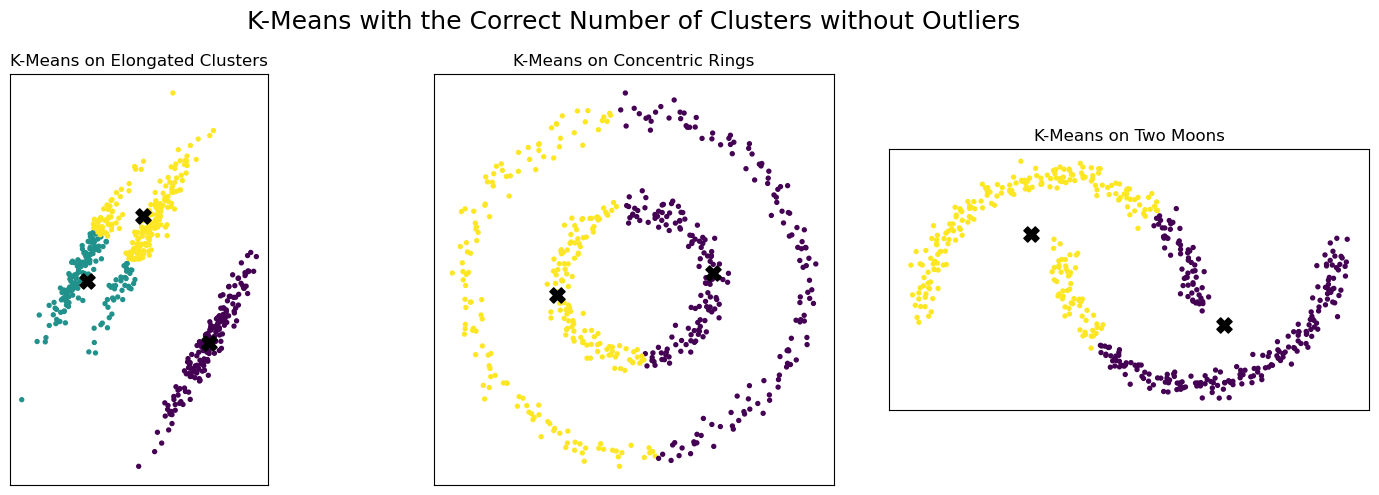

In [27]:
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# Helper function for plotting K-Means results
# ------------------------------------------------------------

def plot_kmeans(ax, X, n_clusters, title):
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        s=point_size
    )

    ax.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        c="black",
        marker="X",
        s=120
    )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


# ------------------------------------------------------------
# Recreate datasets without manually labeled outliers
# ------------------------------------------------------------

X_elongated, _ = make_elongated_clusters(seed=42)

X_rings, _ = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.04,
    random_state=42
)

X_moons, _ = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# ------------------------------------------------------------
# Plot K-Means results
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_kmeans(
    axes[0],
    X_elongated,
    n_clusters=3,
    title="K-Means on Elongated Clusters"
)

plot_kmeans(
    axes[1],
    X_rings,
    n_clusters=2,
    title="K-Means on Concentric Rings"
)

plot_kmeans(
    axes[2],
    X_moons,
    n_clusters=2,
    title="K-Means on Two Moons"
)

plt.suptitle(
    "K-Means with the Correct Number of Clusters without Outliers",
    fontsize=18
)

plt.tight_layout()
plt.show()

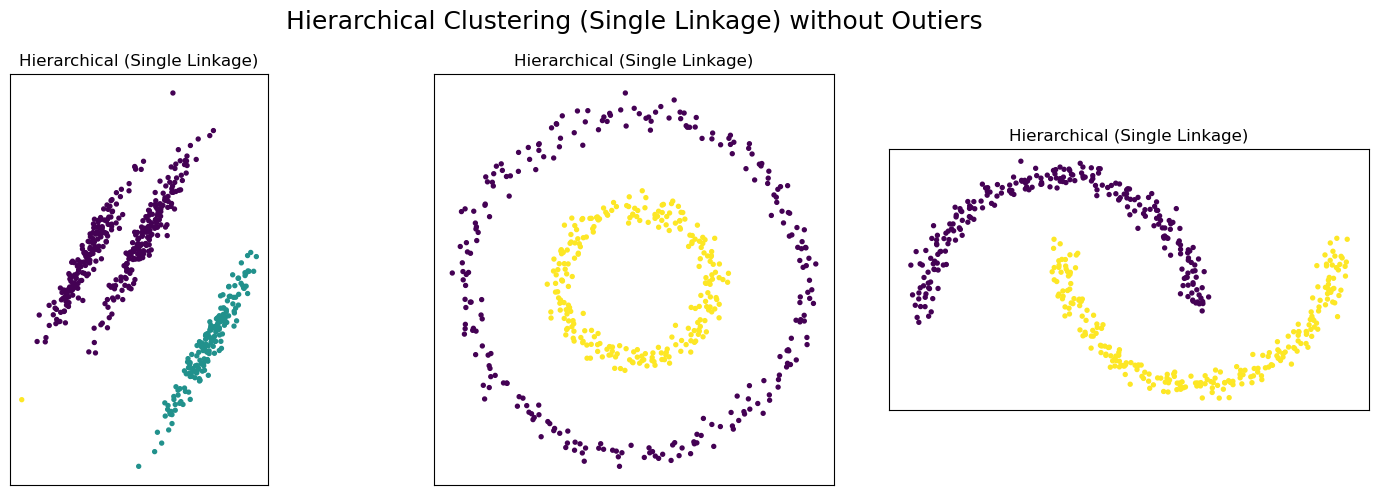

In [26]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_circles, make_moons

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def plot_hierarchical(ax, X, n_clusters, title):

    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="single"
    )

    labels = model.fit_predict(X)

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        s=point_size
    )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


# ------------------------------------------------------------
# Recreate datasets
# ------------------------------------------------------------

X_elongated, _ = make_elongated_clusters(seed=42)

X_rings, _ = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.04,
    random_state=42
)

X_moons, _ = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_hierarchical(
    axes[0],
    X_elongated,
    n_clusters=3,
    title="Hierarchical (Single Linkage)"
)

plot_hierarchical(
    axes[1],
    X_rings,
    n_clusters=2,
    title="Hierarchical (Single Linkage)"
)

plot_hierarchical(
    axes[2],
    X_moons,
    n_clusters=2,
    title="Hierarchical (Single Linkage)"
)

plt.suptitle(
    "Hierarchical Clustering (Single Linkage) without Outiers",
    fontsize=18
)

plt.tight_layout()
plt.show()

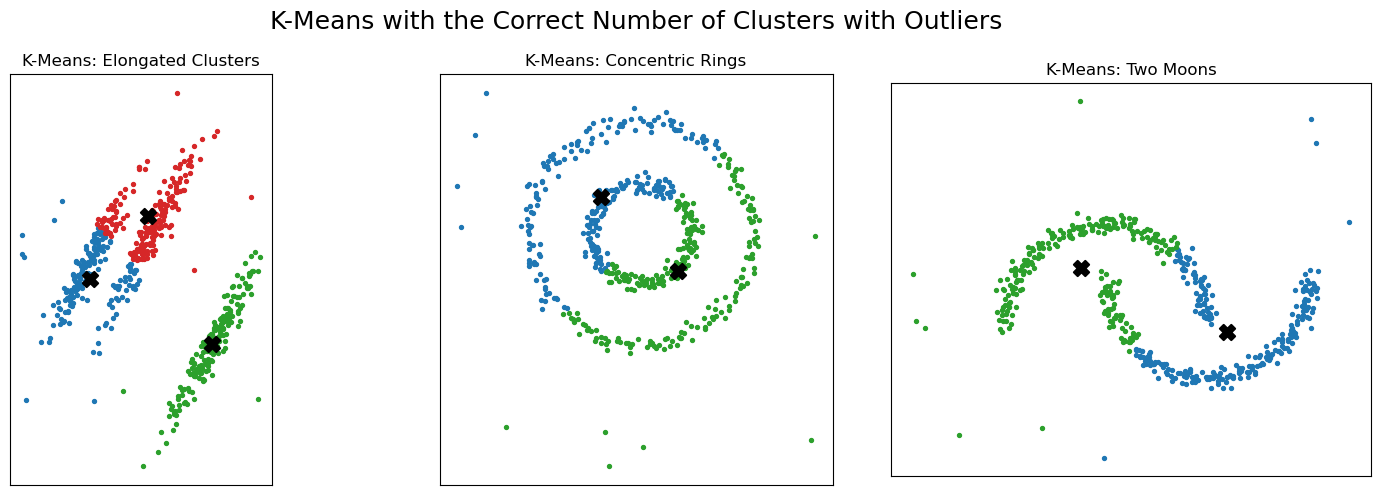

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles, make_moons
from sklearn.cluster import KMeans


# ------------------------------------------------------------
# Create outliers that are far from existing data points
# ------------------------------------------------------------

def create_outliers_away_from_data(
    X,
    n_outliers=10,
    low=-2.3,
    high=2.3,
    min_distance=0.50,
    seed=42
):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)

        distances = np.linalg.norm(X - p, axis=1)

        if distances.min() > min_distance:
            outliers.append(p)

    return np.array(outliers)


# ------------------------------------------------------------
# Create outliers outside circular clusters
# ------------------------------------------------------------

def create_ring_outliers(
    n_outliers=10,
    low=-2.3,
    high=2.3,
    min_radius=1.55,
    seed=42
):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)

        if np.linalg.norm(p) > min_radius:
            outliers.append(p)

    return np.array(outliers)


# ------------------------------------------------------------
# Create elongated parallel clusters
# ------------------------------------------------------------

def make_elongated_clusters(seed=42):

    rng = np.random.RandomState(seed)

    centers = [
        [-0.8,  0.6],
        [ 0.0,  0.9],
        [ 0.8, -0.6]
    ]

    X_all = []
    y_all = []

    for i, center in enumerate(centers):

        n = 180

        x = rng.normal(0, 0.08, size=n)
        y = rng.normal(0, 0.65, size=n)

        X = np.column_stack([x, y])

        theta = np.deg2rad(-28)

        R = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta),  np.cos(theta)]
        ])

        X = X @ R.T
        X = X + np.array(center)

        X_all.append(X)
        y_all.append(np.full(n, i))

    return np.vstack(X_all), np.concatenate(y_all)


# ------------------------------------------------------------
# Plot K-Means results
# ------------------------------------------------------------

def plot_kmeans(ax, X, n_clusters, title):

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    cluster_colors = [
        "#1f77b4",  # blue
        "#2ca02c",  # green
        "#d62728"   # red
    ]

    for k in range(n_clusters):
        ax.scatter(
            X[labels == k, 0],
            X[labels == k, 1],
            color=cluster_colors[k],
            s=8
        )

    ax.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        color="black",
        marker="X",
        s=120,
        linewidths=1.5
    )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

n_outliers = 10


# ============================================================
# Elongated clusters + outliers
# ============================================================

X_elongated, _ = make_elongated_clusters(seed=42)

outliers_elongated = create_outliers_away_from_data(
    X_elongated,
    n_outliers=n_outliers,
    low=-1.8,
    high=1.8,
    min_distance=0.50,
    seed=1
)

X_elongated = np.vstack([
    X_elongated,
    outliers_elongated
])


# ============================================================
# Rings + outliers
# ============================================================

X_rings, _ = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.04,
    random_state=42
)

outliers_rings = create_ring_outliers(
    n_outliers=n_outliers,
    low=-2.2,
    high=2.2,
    min_radius=1.55,
    seed=2
)

X_rings = np.vstack([
    X_rings,
    outliers_rings
])


# ============================================================
# Moons + outliers
# ============================================================

X_moons, _ = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

outliers_moons = create_outliers_away_from_data(
    X_moons,
    n_outliers=n_outliers,
    low=-2.0,
    high=2.5,
    min_distance=0.50,
    seed=3
)

X_moons = np.vstack([
    X_moons,
    outliers_moons
])


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_kmeans(
    axes[0],
    X_elongated,
    n_clusters=3,
    title="K-Means: Elongated Clusters"
)

plot_kmeans(
    axes[1],
    X_rings,
    n_clusters=2,
    title="K-Means: Concentric Rings"
)

plot_kmeans(
    axes[2],
    X_moons,
    n_clusters=2,
    title="K-Means: Two Moons"
)

plt.suptitle(
    "K-Means with the Correct Number of Clusters with Outliers",
    fontsize=18
)

plt.tight_layout()
plt.show()

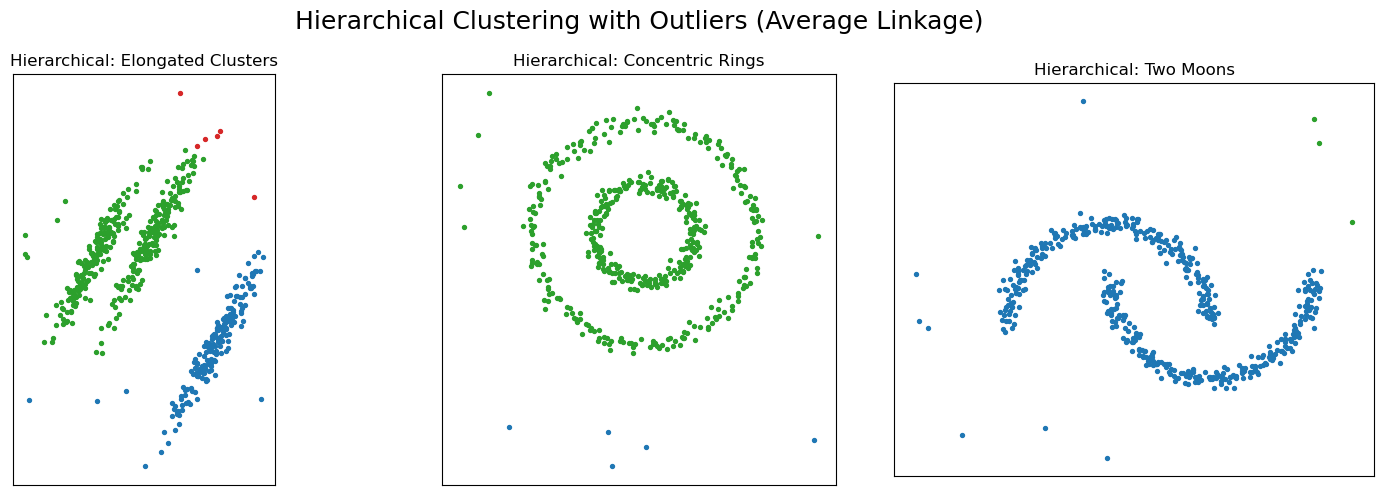

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles, make_moons
from sklearn.cluster import AgglomerativeClustering


def create_outliers_away_from_data(X, n_outliers=10, low=-2.3, high=2.3,
                                   min_distance=0.50, seed=42):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)
        distances = np.linalg.norm(X - p, axis=1)

        if distances.min() > min_distance:
            outliers.append(p)

    return np.array(outliers)


def create_ring_outliers(n_outliers=10, low=-2.3, high=2.3,
                         min_radius=1.55, seed=42):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)

        if np.linalg.norm(p) > min_radius:
            outliers.append(p)

    return np.array(outliers)


def make_elongated_clusters(seed=42):
    rng = np.random.RandomState(seed)

    centers = [
        [-0.8,  0.6],
        [ 0.0,  0.9],
        [ 0.8, -0.6]
    ]

    X_all = []
    y_all = []

    for i, center in enumerate(centers):
        n = 180

        x = rng.normal(0, 0.08, size=n)
        y = rng.normal(0, 0.65, size=n)

        X = np.column_stack([x, y])

        theta = np.deg2rad(-28)

        R = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta),  np.cos(theta)]
        ])

        X = X @ R.T
        X = X + np.array(center)

        X_all.append(X)
        y_all.append(np.full(n, i))

    return np.vstack(X_all), np.concatenate(y_all)


def plot_hierarchical(ax, X, n_clusters, title, linkage="average"):
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage
    )

    labels = model.fit_predict(X)

    cluster_colors = [
        "#1f77b4",  # blue
        "#2ca02c",  # green
        "#d62728"   # red
    ]

    for k in range(n_clusters):
        ax.scatter(
            X[labels == k, 0],
            X[labels == k, 1],
            color=cluster_colors[k],
            s=8
        )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

n_outliers = 10
linkage_method = "average"   # Try "complete" also


# ============================================================
# Elongated clusters + outliers
# ============================================================

X_elongated, _ = make_elongated_clusters(seed=42)

outliers_elongated = create_outliers_away_from_data(
    X_elongated,
    n_outliers=n_outliers,
    low=-1.8,
    high=1.8,
    min_distance=0.50,
    seed=1
)

X_elongated = np.vstack([X_elongated, outliers_elongated])


# ============================================================
# Rings + outliers
# ============================================================

X_rings, _ = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.04,
    random_state=42
)

outliers_rings = create_ring_outliers(
    n_outliers=n_outliers,
    low=-2.2,
    high=2.2,
    min_radius=1.55,
    seed=2
)

X_rings = np.vstack([X_rings, outliers_rings])


# ============================================================
# Moons + outliers
# ============================================================

X_moons, _ = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

outliers_moons = create_outliers_away_from_data(
    X_moons,
    n_outliers=n_outliers,
    low=-2.0,
    high=2.5,
    min_distance=0.50,
    seed=3
)

X_moons = np.vstack([X_moons, outliers_moons])


# ------------------------------------------------------------
# Plot hierarchical clustering results
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_hierarchical(
    axes[0],
    X_elongated,
    n_clusters=3,
    title="Hierarchical: Elongated Clusters",
    linkage=linkage_method
)

plot_hierarchical(
    axes[1],
    X_rings,
    n_clusters=2,
    title="Hierarchical: Concentric Rings",
    linkage=linkage_method
)

plot_hierarchical(
    axes[2],
    X_moons,
    n_clusters=2,
    title="Hierarchical: Two Moons",
    linkage=linkage_method
)

plt.suptitle(
    f"Hierarchical Clustering with Outliers ({linkage_method.capitalize()} Linkage)",
    fontsize=18
)

plt.tight_layout()
plt.show()

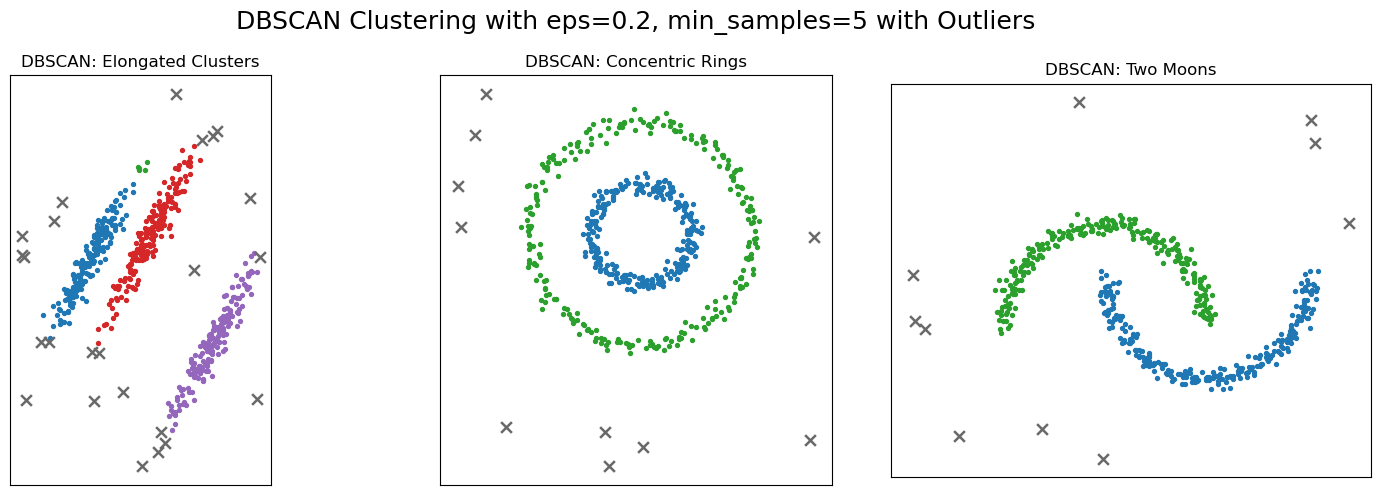

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles, make_moons
from sklearn.cluster import DBSCAN


# ------------------------------------------------------------
# DBSCAN hyperparameters
# ------------------------------------------------------------

eps = 0.20          # Neighborhood radius
min_samples = 5    # Minimum points needed to form a dense region


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def create_outliers_away_from_data(X, n_outliers=10, low=-2.3, high=2.3,
                                   min_distance=0.50, seed=42):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)
        distances = np.linalg.norm(X - p, axis=1)

        if distances.min() > min_distance:
            outliers.append(p)

    return np.array(outliers)


def create_ring_outliers(n_outliers=10, low=-2.3, high=2.3,
                         min_radius=1.55, seed=42):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)

        if np.linalg.norm(p) > min_radius:
            outliers.append(p)

    return np.array(outliers)


def make_elongated_clusters(seed=42):
    rng = np.random.RandomState(seed)

    centers = [
        [-0.8,  0.6],
        [ 0.0,  0.9],
        [ 0.8, -0.6]
    ]

    X_all = []
    y_all = []

    for i, center in enumerate(centers):
        n = 180

        x = rng.normal(0, 0.08, size=n)
        y = rng.normal(0, 0.65, size=n)

        X = np.column_stack([x, y])

        theta = np.deg2rad(-28)

        R = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta),  np.cos(theta)]
        ])

        X = X @ R.T
        X = X + np.array(center)

        X_all.append(X)
        y_all.append(np.full(n, i))

    return np.vstack(X_all), np.concatenate(y_all)


def plot_dbscan(ax, X, title, eps, min_samples):
    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(X)

    cluster_colors = [
        "#1f77b4",  # blue
        "#2ca02c",  # green
        "#d62728",  # red
        "#9467bd",  # purple, backup
        "#ff7f0e"   # orange, backup
    ]

    # Plot clusters
    cluster_labels = sorted(label for label in set(labels) if label != -1)

    for i, label in enumerate(cluster_labels):
        ax.scatter(
            X[labels == label, 0],
            X[labels == label, 1],
            color=cluster_colors[i % len(cluster_colors)],
            s=8
        )

    # Plot noise points
    noise = labels == -1

    ax.scatter(
        X[noise, 0],
        X[noise, 1],
        color="dimgray",
        marker="x",
        s=60,
        linewidths=1.8
    )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


# ------------------------------------------------------------
# Parameters for generated datasets
# ------------------------------------------------------------

n_outliers = 10


# ============================================================
# Elongated clusters + outliers
# ============================================================

X_elongated, _ = make_elongated_clusters(seed=42)

outliers_elongated = create_outliers_away_from_data(
    X_elongated,
    n_outliers=n_outliers,
    low=-1.8,
    high=1.8,
    min_distance=0.50,
    seed=1
)

X_elongated = np.vstack([X_elongated, outliers_elongated])


# ============================================================
# Rings + outliers
# ============================================================

X_rings, _ = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.04,
    random_state=42
)

outliers_rings = create_ring_outliers(
    n_outliers=n_outliers,
    low=-2.2,
    high=2.2,
    min_radius=1.55,
    seed=2
)

X_rings = np.vstack([X_rings, outliers_rings])


# ============================================================
# Moons + outliers
# ============================================================

X_moons, _ = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

outliers_moons = create_outliers_away_from_data(
    X_moons,
    n_outliers=n_outliers,
    low=-2.0,
    high=2.5,
    min_distance=0.50,
    seed=3
)

X_moons = np.vstack([X_moons, outliers_moons])


# ------------------------------------------------------------
# Plot DBSCAN results
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_dbscan(
    axes[0],
    X_elongated,
    title="DBSCAN: Elongated Clusters",
    eps=eps,
    min_samples=min_samples
)

plot_dbscan(
    axes[1],
    X_rings,
    title="DBSCAN: Concentric Rings",
    eps=eps,
    min_samples=min_samples
)

plot_dbscan(
    axes[2],
    X_moons,
    title="DBSCAN: Two Moons",
    eps=eps,
    min_samples=min_samples
)

plt.suptitle(
    f"DBSCAN Clustering with eps={eps}, min_samples={min_samples} with Outliers",
    fontsize=18
)

plt.tight_layout()
plt.show()

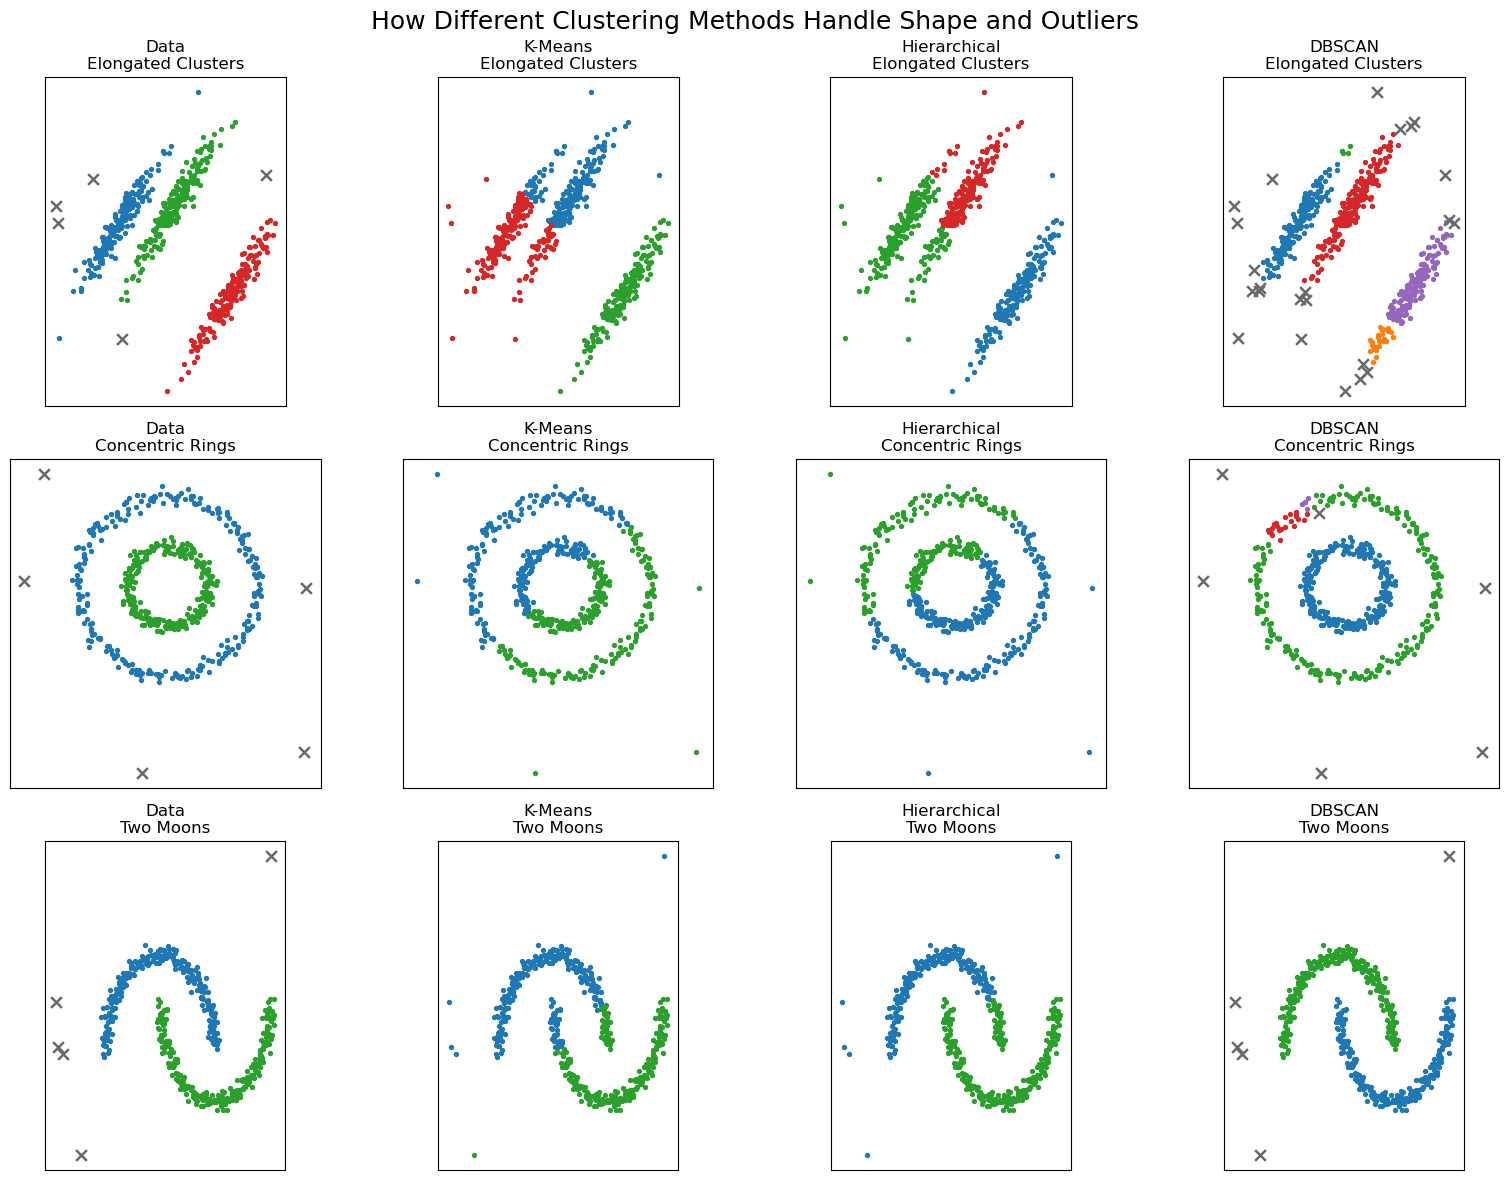

In [34]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles, make_moons
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------

random_seed = 42
n_outliers = 5

eps = 0.20
min_samples = 5


# ------------------------------------------------------------
# Helper functions for creating datasets
# ------------------------------------------------------------

def create_outliers_away_from_data(X, n_outliers=5, low=-2.3, high=2.3,
                                   min_distance=0.50, seed=42):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)
        distances = np.linalg.norm(X - p, axis=1)

        if distances.min() > min_distance:
            outliers.append(p)

    return np.array(outliers)


def create_ring_outliers(n_outliers=5, low=-2.3, high=2.3,
                         min_radius=1.55, seed=42):
    rng = np.random.RandomState(seed)
    outliers = []

    while len(outliers) < n_outliers:
        p = rng.uniform(low=low, high=high, size=2)

        if np.linalg.norm(p) > min_radius:
            outliers.append(p)

    return np.array(outliers)


def make_elongated_clusters(seed=42):
    rng = np.random.RandomState(seed)

    centers = [
        [-0.8,  0.6],
        [ 0.0,  0.9],
        [ 0.8, -0.6]
    ]

    X_all = []
    y_all = []

    for i, center in enumerate(centers):
        n = 180

        x = rng.normal(0, 0.08, size=n)
        y = rng.normal(0, 0.65, size=n)

        X = np.column_stack([x, y])

        theta = np.deg2rad(-28)

        R = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta),  np.cos(theta)]
        ])

        X = X @ R.T
        X = X + np.array(center)

        X_all.append(X)
        y_all.append(np.full(n, i))

    return np.vstack(X_all), np.concatenate(y_all)


def add_outliers(X, y, outliers):
    X_with_outliers = np.vstack([X, outliers])

    y_with_outliers = np.concatenate([
        y,
        np.full(len(outliers), -1)
    ])

    outlier_mask = y_with_outliers == -1

    return X_with_outliers, y_with_outliers, outlier_mask


# ------------------------------------------------------------
# Plotting helpers
# ------------------------------------------------------------

cluster_colors = [
    "#1f77b4",  # blue
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#ff7f0e"   # orange
]


def plot_data_column(ax, X, y_true, outlier_mask, title):
    """
    First column: show the intended/obvious cluster structure.
    Outliers are shown as gray X's.
    """

    cluster_labels = sorted(label for label in set(y_true) if label != -1)

    for i, label in enumerate(cluster_labels):
        mask = (y_true == label) & (~outlier_mask)

        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            color=cluster_colors[i % len(cluster_colors)],
            s=8
        )

    ax.scatter(
        X[outlier_mask, 0],
        X[outlier_mask, 1],
        color="dimgray",
        marker="x",
        s=60,
        linewidths=1.8
    )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def plot_method_result(ax, X, labels, title, show_noise=False):
    """
    Algorithm columns.

    For K-Means and Hierarchical:
        show_noise=False, so every point is colored as part of a cluster.

    For DBSCAN:
        show_noise=True, so points labeled -1 are shown as gray X's.
    """

    if show_noise:
        noise_mask = labels == -1
    else:
        noise_mask = np.zeros(len(labels), dtype=bool)

    cluster_labels = sorted(label for label in set(labels) if label != -1)

    for i, label in enumerate(cluster_labels):
        mask = (labels == label) & (~noise_mask)

        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            color=cluster_colors[i % len(cluster_colors)],
            s=8
        )

    if np.any(noise_mask):
        ax.scatter(
            X[noise_mask, 0],
            X[noise_mask, 1],
            color="dimgray",
            marker="x",
            s=60,
            linewidths=1.8
        )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


# ------------------------------------------------------------
# Create datasets with true labels and outliers
# ------------------------------------------------------------

# Elongated clusters
X_elongated, y_elongated = make_elongated_clusters(seed=42)

outliers_elongated = create_outliers_away_from_data(
    X_elongated,
    n_outliers=n_outliers,
    low=-1.8,
    high=1.8,
    min_distance=0.50,
    seed=1
)

X_elongated, y_elongated, outlier_mask_elongated = add_outliers(
    X_elongated,
    y_elongated,
    outliers_elongated
)


# Concentric rings
X_rings, y_rings = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.04,
    random_state=42
)

outliers_rings = create_ring_outliers(
    n_outliers=n_outliers,
    low=-2.2,
    high=2.2,
    min_radius=1.55,
    seed=2
)

X_rings, y_rings, outlier_mask_rings = add_outliers(
    X_rings,
    y_rings,
    outliers_rings
)


# Two moons
X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

outliers_moons = create_outliers_away_from_data(
    X_moons,
    n_outliers=n_outliers,
    low=-2.0,
    high=2.5,
    min_distance=0.50,
    seed=3
)

X_moons, y_moons, outlier_mask_moons = add_outliers(
    X_moons,
    y_moons,
    outliers_moons
)


datasets = [
    ("Elongated Clusters", X_elongated, y_elongated, outlier_mask_elongated, 3),
    ("Concentric Rings", X_rings, y_rings, outlier_mask_rings, 2),
    ("Two Moons", X_moons, y_moons, outlier_mask_moons, 2),
]


# ------------------------------------------------------------
# Compare Data, K-Means, Hierarchical Clustering, and DBSCAN
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=len(datasets),
    ncols=4,
    figsize=(16, 12)
)

for row, (dataset_name, X, y_true, outlier_mask, n_clusters) in enumerate(datasets):

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    models = [
        (
            "K-Means",
            KMeans(
                n_clusters=n_clusters,
                random_state=random_seed,
                n_init=10
            ),
            False
        ),
        (
            "Hierarchical",
            AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage="ward"
            ),
            False
        ),
        (
            "DBSCAN",
            DBSCAN(
                eps=eps,
                min_samples=min_samples
            ),
            True
        )
    ]

    # First column: intended data structure
    plot_data_column(
        axes[row, 0],
        X_scaled,
        y_true,
        outlier_mask,
        title=f"Data\n{dataset_name}"
    )

    # Algorithm columns
    for col, (method_name, model, show_noise) in enumerate(models, start=1):

        labels = model.fit_predict(X_scaled)

        plot_method_result(
            axes[row, col],
            X_scaled,
            labels,
            title=f"{method_name}\n{dataset_name}",
            show_noise=show_noise
        )


plt.suptitle(
    "How Different Clustering Methods Handle Shape and Outliers",
    fontsize=18
)

plt.tight_layout()
plt.show()